1. 以上的gnn实现了同时更新node和edge embedding的功能，但是其没有考虑到不同type的edge，node 的情况，依然属于一种hemogeneous graph</br >
2. 从资料来看sage gnn效果是否比gat要好，或者不同的场景效果有差异
3. 继续考虑如何结合neo4j 和pyg实现真实数据的实验
-------

总结：下一步工作：
0. 实现neo4j 与pgy的结合，从而读取真实数据，构建gnn。
1. 结合论文的特征，边语义也非常重要，故应该考虑不但更新node 的embdding，而且还要更新edge 的embedding。
2. 结合语义，对应的graph显然是个heterogeneous graph，不同type的edge，node 有不同的embedding，应该考虑到这一点。
3. 对于hidden embbding 的训练，目前资料提供的是基于分类的训练任务，但研究的数据集中，如果是分类，实际只能是不同节点的语义类别（例如claim，statement），但其类别非常多，选取某个类别进行分类训练，是否会导致其他语义类别的信息丢失。</br>
   是否可以考虑使用mask，类似于bert，构建node与edge 的hidden embdding，用于下游任务，同时在输入原始信息，构成static embedding（输入gnn的emdding）是否可以选择以下属性：
   * text：node，edge对应的原始文本（必选）
   * node，edge语义类型，例如claim，statement，supports，challenges等以及是否附加类型的定义?
   * 图分析得到的结果信息，例如节点的中心度，betweenness， 聚类归属。
  
4. 下游任务中，结合本研究的目标可以包括：
    * 预测关系，特别是support/challenge 等论证语义，从而发现论文间，不同论文间的新的论证网络。
    * 相似节点聚类，这里不基于图论聚类方法，而是基于hidden embdding 进行聚类。·类似于berttopic，但得到的结果是基于论文的图节点、边的文本embbding，以及结合了结构的gnn训练得到的hidden embdding。</br>
      从而发现的论文潜在主题聚类是一种基于论证结构的聚类，而不是单纯基于文本的聚类。
    * graph rag 中 re-ranking 的结合,结合gnn，首先人工对论文中具体的claim，statement进行打分标注（或者对其所属大的论证模块，甚至论文本身进行打分），从而得到label，再在此基础上对其他论文进行打分，从而得到新的ranked list。</bt>
      此方法的使用场景适合于新论文，其还没有被广泛引用，难以判断其质量好坏，或者论文所在期刊得分一般，难以作为直接参考。

##  step 0. 构建SEG 图摘要子图，作为gnn的分析目标
 
gnn的对象首先面向SEG子图，其来源于为Master node，Master relation 是整个图的摘要，对应节点较少，能比较好的进行分析

2025-12-21 10:13:11,669 - ERROR - 投影失败: Couldn't connect to localhost:7687 (resolved to ('127.0.0.1:7687', '[::1]:7687')):
Failed to establish connection to ResolvedIPv4Address(('127.0.0.1', 7687)) (reason [WinError 10061] 由于目标计算机积极拒绝，无法连接。)
Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [WinError 10061] 由于目标计算机积极拒绝，无法连接。)
2025-12-21 10:13:21,993 - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The procedure has a deprecated field. ('schema' returned by 'gds.graph.list' is deprecated.)} {position: line: 2, column: 78, offset: 78} for query: '\n        CALL gds.graph.list($graph_name) YIELD nodeCount, relationshipCount, schema\n        WITH nodeCount, relationshipCount, [k IN keys(schema.relationships) | k] AS relTypes\n        UNWIND relTypes AS relT

--------------------------------------------------
✨ 语义质量统计 (master_score)
平均置信度: 0.7997
置信度区间: [0.50 - 0.95]



2025-12-21 10:13:23,841 - INFO - 获取图数据: 4310 个节点, 1744 条边



📈 图拓扑分析
节点数: 4310
边数: 1659
图密度: 0.0001

度数统计:
  平均度数: 0.77
  平均入度: 0.38
  平均出度: 0.38

Top 5 核心节点 (按度数):
  Unnamed                        | 度数: 12
  Unnamed                        | 度数: 11
  Successful Sulfur and Zinc Co- | 度数: 10
  Unnamed                        | 度数: 10
  Unnamed                        | 度数: 10

图连通性: 非连通 (2769 个弱连通分量)
  最大分量大小: 124



2025-12-21 10:13:24,579 - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' has been replaced by 'elementId or an application-generated id')} {position: line: 4, column: 13, offset: 57} for query: '\n        MATCH (n:__Master__)\n        RETURN\n            id(n) AS id,\n            labels(n) AS labels,\n            n.WHU_HASNAME AS name,\n            n.WHU_HASORIGINALTEXT AS text,\n            n.embedding AS node_emb\n        '
2025-12-21 10:13:26,034 - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' h


开始可视化...


2025-12-21 10:13:26,701 - INFO - 获取图数据: 500 个节点, 135 条边
2025-12-21 10:13:26,704 - INFO - NetworkX图构建完成: 500 节点, 122 边
2025-12-21 10:13:26,704 - INFO - 计算布局 (spring)...
2025-12-21 10:13:29,063 - INFO - 图形已保存至: seg_graph_spring.png


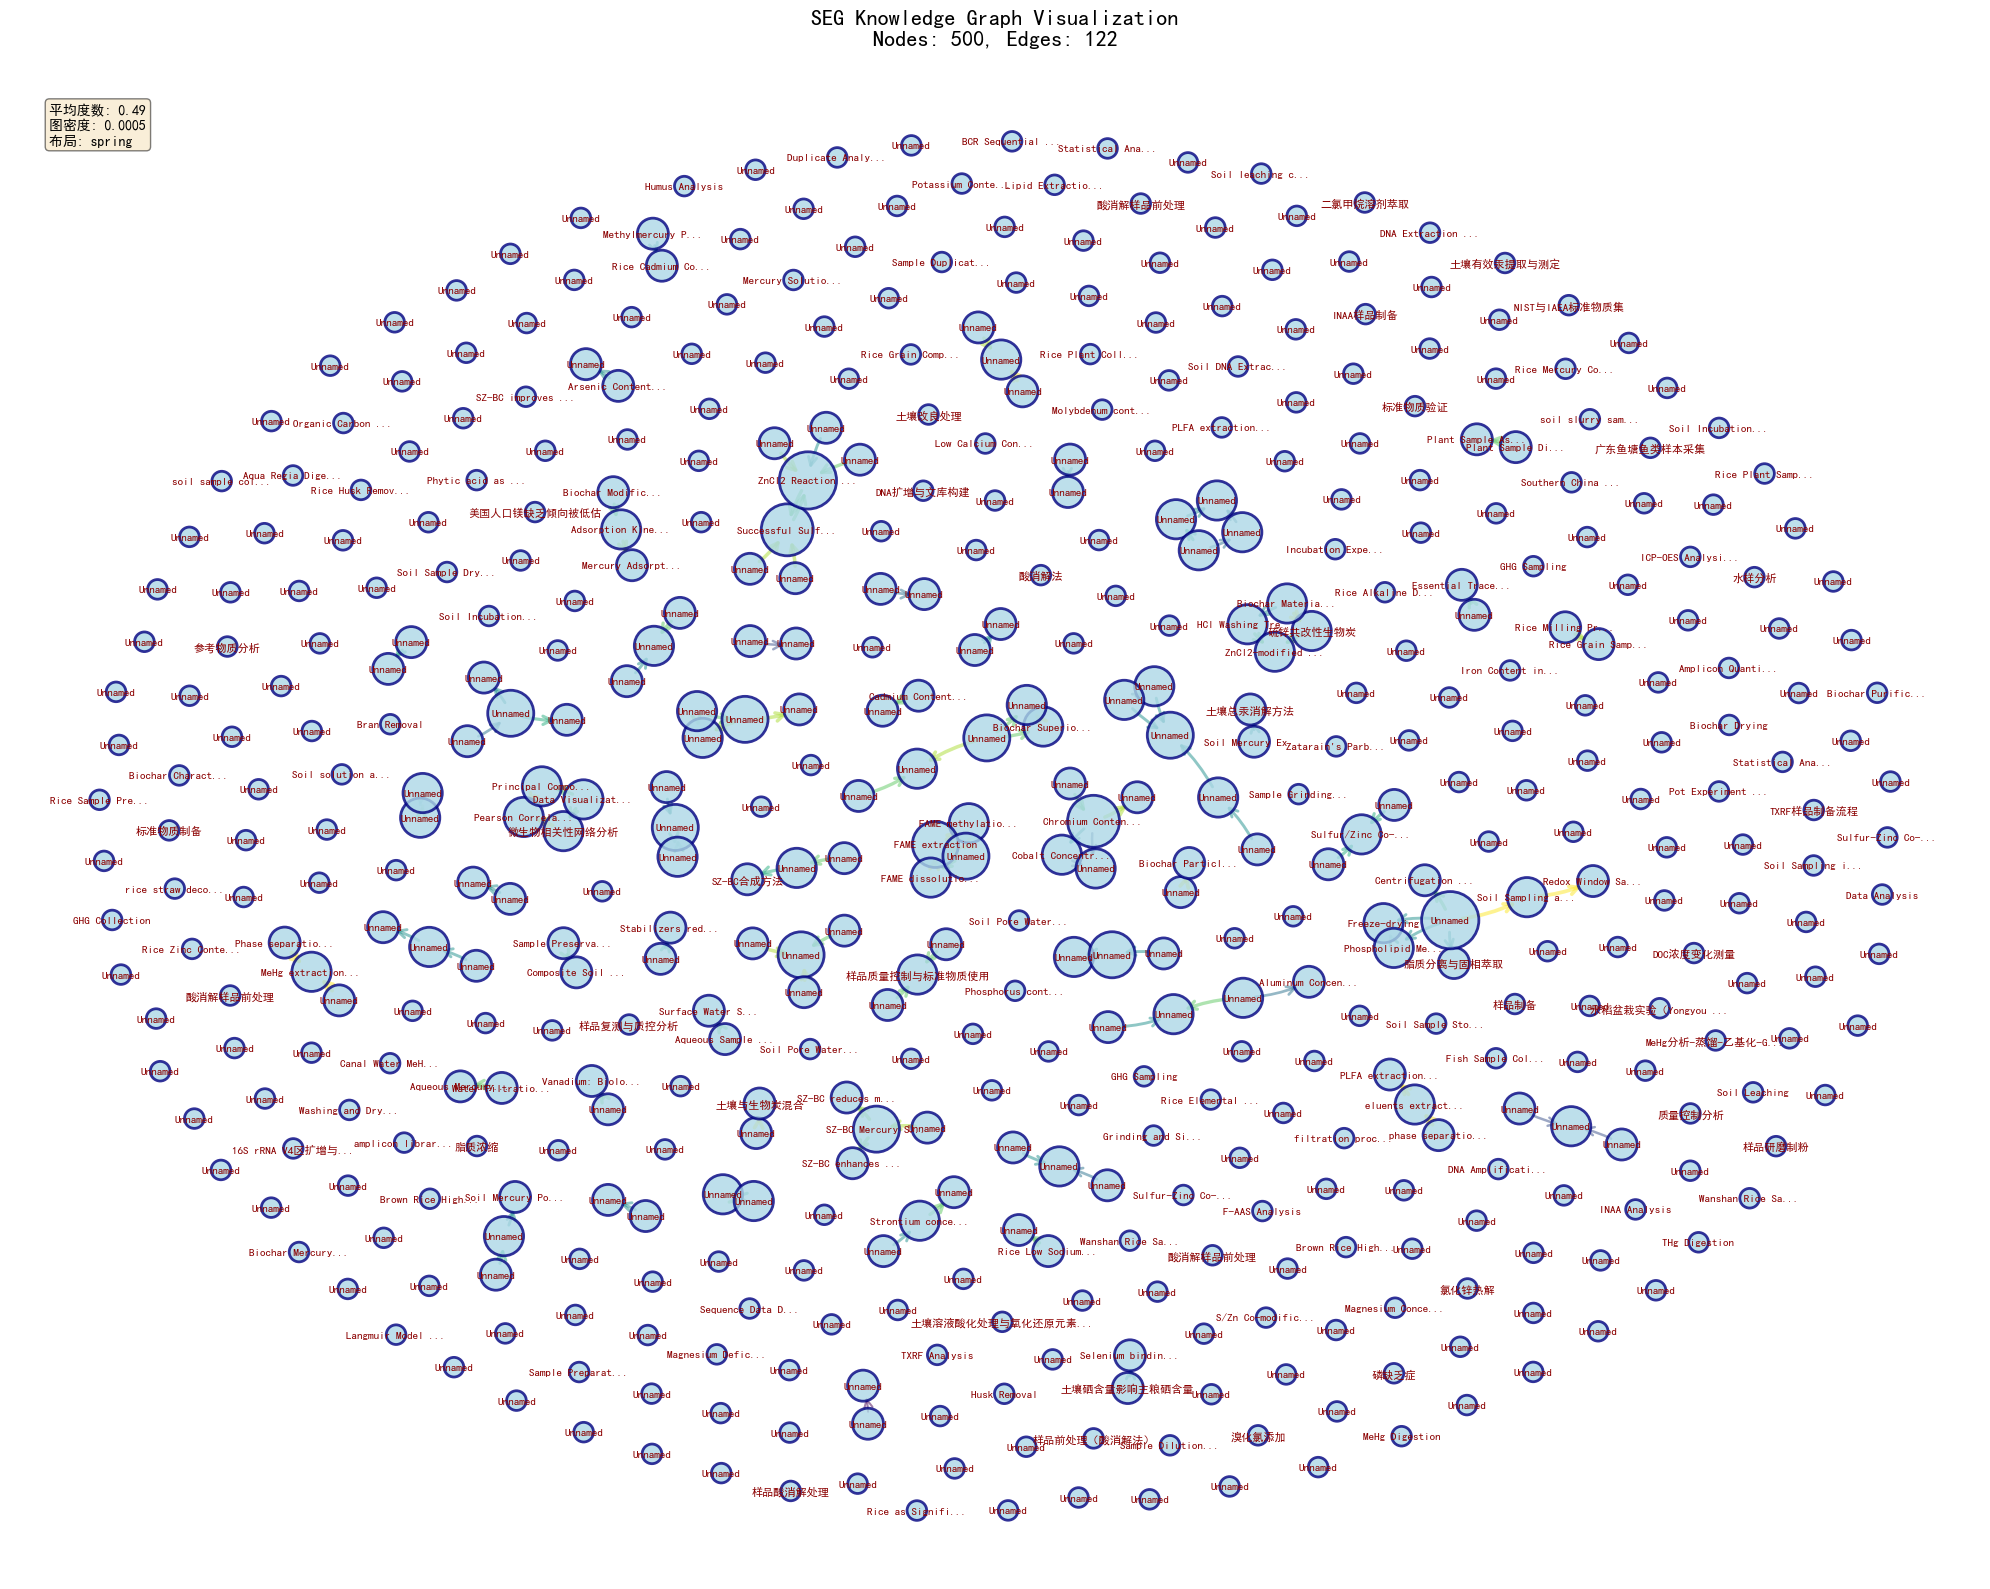

2025-12-21 10:13:29,623 - INFO - 可视化完成


In [1]:
import logging
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import font_manager
from utilities import return_llm_database as rldb

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class SEGAnalyzer:
    def __init__(self):
        self.driver = rldb.DatabaseManager.get_neo4j_driver(remotedatebase=False)
        self.graph_name = "SEG_In_Memory_Graph"
        self._setup_chinese_font()

    def _setup_chinese_font(self):
        """配置中文字体显示"""
        try:
            plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS']
            plt.rcParams['axes.unicode_minus'] = False
        except:
            logger.warning("中文字体配置失败，将使用默认字体")
    def get_SEG(self) -> dict:
        """
        返回用于 GNN 计算的 SEG 子图对象（Python 层）
        包含：
          - nodes: id, labels, WHU_HASNAME, WHU_HASORIGINALTEXT, node_emb
          - edges: source, target, type, weight(master_score), edge_emb
        约定：
          - 所有 node id / edge endpoint 使用 id(n)，与 GDS projection 一致
        """
        node_query = """
        MATCH (n:__Master__)
        RETURN
            id(n) AS id,
            labels(n) AS labels,
            n.WHU_HASNAME AS name,
            n.WHU_HASORIGINALTEXT AS text,
            n.embedding AS node_emb
        """

        edge_query = """
        MATCH (s:__Master__)-[r]->(t:__Master__)
        WHERE type(r) STARTS WITH 'MASTER_'
        RETURN
            id(s) AS source,
            id(t) AS target,
            type(r) AS type,
            coalesce(r.master_score, 0.5) AS weight,
            r.embedding AS edge_emb
        """

        with self.driver.session() as session:
            # -------- nodes --------
            nodes = []
            node_ids = set()
            for rec in session.run(node_query):
                nid = rec["id"]
                node_ids.add(nid)
                nodes.append({
                    "id": nid,
                    "labels": rec["labels"],
                    "name": rec["name"] or "Unnamed",
                    "text": rec["text"],
                    "node_emb": rec["node_emb"]  # 可能为 None
                })

            # -------- edges --------
            edges = []
            for rec in session.run(edge_query):
                # 保证边端点存在（稳妥）
                if rec["source"] in node_ids and rec["target"] in node_ids:
                    edges.append({
                        "source": rec["source"],
                        "target": rec["target"],
                        "type": rec["type"],
                        "weight": float(rec["weight"]),
                        "edge_emb": rec["edge_emb"]  # 可能为 None
                    })

        logger.info(
            f"SEG object loaded for GNN: {len(nodes)} nodes, {len(edges)} edges"
        )

        return {
            "graph_name": self.graph_name,
            "nodes": nodes,
            "edges": edges
        }
  
    def project_seg_graph(self):
        """利用 GDS 投影建立 SEG 内存图"""
        query = """
        CALL gds.graph.project.cypher(
            $graph_name,
            "MATCH (n:__Master__) RETURN id(n) AS id, labels(n) AS labels",
            "MATCH (s:__Master__)-[r]->(t:__Master__) 
             WHERE type(r) STARTS WITH 'MASTER_' 
             RETURN id(s) AS source, id(t) AS target, type(r) AS type, r.master_score AS weight",
            {validateRelationships: true}
        )
        """
        try:
            with self.driver.session() as session:
                # 删除已存在的图
                session.run(f"CALL gds.graph.drop('{self.graph_name}', false)")
                
                logger.info(f"正在建立 GDS 投影: {self.graph_name}...")
                result = session.run(query, graph_name=self.graph_name).single()
                logger.info(f"投影成功。节点数: {result['nodeCount']}, 关系数: {result['relationshipCount']}")
        except Exception as e:
            logger.error(f"投影失败: {e}")

    def get_seg_statistics(self):
        """统计 SEG 的全貌：节点、关系分布及权重分布"""
        stats_query = """
        CALL gds.graph.list($graph_name) YIELD nodeCount, relationshipCount, schema
        WITH nodeCount, relationshipCount, [k IN keys(schema.relationships) | k] AS relTypes
        UNWIND relTypes AS relType
        MATCH (:__Master__)-[r]->(:__Master__)
        WHERE type(r) = relType
        RETURN nodeCount, relationshipCount, relType, count(r) AS relCount
        """
        
        score_query = """
        MATCH (:__Master__)-[r]->(:__Master__)
        WHERE type(r) STARTS WITH 'MASTER_'
        RETURN 
            min(r.master_score) AS min_score,
            max(r.master_score) AS max_score,
            avg(r.master_score) AS avg_score
        """

        try:
            with self.driver.session() as session:
                # 结构与关系分布统计
                results = session.run(stats_query, graph_name=self.graph_name)
                
                first_record = None
                rel_data = []
                for record in results:
                    if not first_record: 
                        first_record = record
                    rel_data.append((record['relType'], record['relCount']))

                if first_record:
                    print("\n" + "="*50)
                    print(f"📊 SEG 内存图统计 (GDS Projection)")
                    print(f"总节点数 (Master Nodes): {first_record['nodeCount']}")
                    print(f"总关系数 (Master Relations): {first_record['relationshipCount']}")
                    print("-" * 50)
                    print(f"{'关系类型':<35} | {'数量'}")
                    for name, count in rel_data:
                        print(f"{name:<35} | {count}")
                
                # 质量统计
                score_res = session.run(score_query).single()
                if score_res:
                    print("-" * 50)
                    print(f"✨ 语义质量统计 (master_score)")
                    print(f"平均置信度: {score_res['avg_score']:.4f}")
                    print(f"置信度区间: [{score_res['min_score']:.2f} - {score_res['max_score']:.2f}]")
                print("="*50 + "\n")

        except Exception as e:
            logger.error(f"统计获取失败: {e}")

    def fetch_graph_data(self, limit=None):
        """
        从Neo4j数据库中获取图数据用于可视化
        :param limit: 限制节点数量（None表示全部）
        :return: (nodes, edges) 节点列表和边列表
        """
        # 获取节点数据
        if limit:
            node_query = """
            MATCH (n:__Master__)
            RETURN elementId(n) AS id, 
                   n.WHU_HASNAME AS name,
                   labels(n) AS labels
            LIMIT $limit
            """
        else:
            node_query = """
            MATCH (n:__Master__)
            RETURN elementId(n) AS id, 
                   n.WHU_HASNAME AS name,
                   labels(n) AS labels
            """
        
        # 获取关系数据
        edge_query = """
        MATCH (s:__Master__)-[r]->(t:__Master__)
        WHERE type(r) STARTS WITH 'MASTER_'
        """ + (f"AND elementId(s) IN $node_ids AND elementId(t) IN $node_ids" if limit else "") + """
        RETURN elementId(s) AS source,
               elementId(t) AS target,
               type(r) AS rel_type,
               r.master_score AS weight,
               r.support_count AS support
        """
        
        try:
            with self.driver.session() as session:
                # 获取节点
                node_result = session.run(node_query, limit=limit)
                nodes = []
                node_ids = []
                for record in node_result:
                    nodes.append({
                        'id': record['id'],
                        'name': record['name'] or 'Unnamed',
                        'labels': record['labels']
                    })
                    node_ids.append(record['id'])
                
                # 获取边
                edge_params = {'node_ids': node_ids} if limit else {}
                edge_result = session.run(edge_query, **edge_params)
                edges = []
                for record in edge_result:
                    edges.append({
                        'source': record['source'],
                        'target': record['target'],
                        'type': record['rel_type'],
                        'weight': record['weight'] or 0.5,
                        'support': record['support'] or 1
                    })
                
                logger.info(f"获取图数据: {len(nodes)} 个节点, {len(edges)} 条边")
                return nodes, edges
                
        except Exception as e:
            logger.error(f"获取图数据失败: {e}")
            return [], []

    def visualize_seg_graph(self, limit=100, layout='spring', figsize=(20, 16), 
                           save_path=None, show_labels=True, node_size_scale=300):
        """
        使用NetworkX可视化SEG图
        
        :param limit: 限制显示的节点数量（None表示全部，建议50-200）
        :param layout: 布局算法 ('spring', 'kamada_kawai', 'circular', 'shell')
        :param figsize: 图形尺寸 (宽, 高)
        :param save_path: 保存路径（None表示不保存）
        :param show_labels: 是否显示节点标签
        :param node_size_scale: 节点大小缩放因子
        """
        logger.info("开始构建NetworkX图...")
        
        # 获取数据
        nodes, edges = self.fetch_graph_data(limit)
        if not nodes:
            logger.error("没有获取到图数据")
            return
        
        # 创建有向图
        G = nx.DiGraph()
        
        # 添加节点
        for node in nodes:
            G.add_node(node['id'], name=node['name'], labels=node['labels'])
        
        # 添加边
        for edge in edges:
            if edge['source'] in G.nodes and edge['target'] in G.nodes:
                G.add_edge(edge['source'], edge['target'], 
                          weight=edge['weight'],
                          rel_type=edge['type'],
                          support=edge['support'])
        
        logger.info(f"NetworkX图构建完成: {G.number_of_nodes()} 节点, {G.number_of_edges()} 边")
        
        # 选择布局
        logger.info(f"计算布局 ({layout})...")
        if layout == 'spring':
            pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        elif layout == 'kamada_kawai':
            pos = nx.kamada_kawai_layout(G)
        elif layout == 'circular':
            pos = nx.circular_layout(G)
        elif layout == 'shell':
            pos = nx.shell_layout(G)
        else:
            pos = nx.spring_layout(G, seed=42)
        
        # 创建图形
        fig, ax = plt.subplots(figsize=figsize)
        
        # 计算节点大小（基于度数）
        node_degrees = dict(G.degree())
        node_sizes = [node_degrees[node] * node_size_scale + 200 for node in G.nodes()]
        
        # 绘制节点
        nx.draw_networkx_nodes(
            G, pos, 
            node_size=node_sizes,
            node_color='lightblue',
            alpha=0.8,
            linewidths=2,
            edgecolors='navy',
            ax=ax
        )
        
        # 绘制边（根据权重设置颜色和宽度）
        edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
        edge_widths = [w * 3 for w in edge_weights]
        
        nx.draw_networkx_edges(
            G, pos,
            width=edge_widths,
            alpha=0.5,
            edge_color=edge_weights,
            edge_cmap=plt.cm.viridis,
            arrows=True,
            arrowsize=15,
            arrowstyle='->',
            connectionstyle='arc3,rad=0.1',
            ax=ax
        )
        
        # 绘制节点标签
        if show_labels:
            labels = {node: data['name'][:15] + '...' if len(data['name']) > 15 
                     else data['name'] for node, data in G.nodes(data=True)}
            nx.draw_networkx_labels(
                G, pos, 
                labels=labels,
                font_size=8,
                font_weight='bold',
                font_color='darkred',
                ax=ax
            )
        
        # 添加图例和标题
        ax.set_title(f'SEG Knowledge Graph Visualization\n'
                    f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}',
                    fontsize=16, fontweight='bold', pad=20)
        
        # 添加统计信息
        avg_degree = sum(node_degrees.values()) / len(node_degrees)
        density = nx.density(G)
        info_text = (f"平均度数: {avg_degree:.2f}\n"
                    f"图密度: {density:.4f}\n"
                    f"布局: {layout}")
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.axis('off')
        plt.tight_layout()
        
        # 保存图形
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"图形已保存至: {save_path}")
        
        plt.show()
        logger.info("可视化完成")
        
        return G

    def analyze_graph_metrics(self):
        """分析图的拓扑指标"""
        logger.info("开始分析图拓扑指标...")
        
        nodes, edges = self.fetch_graph_data()
        if not nodes:
            logger.error("无法获取图数据")
            return
        
        G = nx.DiGraph()
        for node in nodes:
            G.add_node(node['id'], name=node['name'])
        for edge in edges:
            if edge['source'] in G.nodes and edge['target'] in G.nodes:
                G.add_edge(edge['source'], edge['target'], weight=edge['weight'])
        
        print("\n" + "="*60)
        print("📈 图拓扑分析")
        print("="*60)
        
        # 基础指标
        print(f"节点数: {G.number_of_nodes()}")
        print(f"边数: {G.number_of_edges()}")
        print(f"图密度: {nx.density(G):.4f}")
        
        # 度数分析
        degrees = dict(G.degree())
        in_degrees = dict(G.in_degree())
        out_degrees = dict(G.out_degree())
        
        print(f"\n度数统计:")
        print(f"  平均度数: {sum(degrees.values())/len(degrees):.2f}")
        print(f"  平均入度: {sum(in_degrees.values())/len(in_degrees):.2f}")
        print(f"  平均出度: {sum(out_degrees.values())/len(out_degrees):.2f}")
        
        # Top节点
        top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"\nTop 5 核心节点 (按度数):")
        for node_id, degree in top_nodes:
            name = G.nodes[node_id]['name']
            print(f"  {name[:30]:<30} | 度数: {degree}")
        
        # 连通性分析
        if nx.is_weakly_connected(G):
            print(f"\n图连通性: 弱连通")
        else:
            components = list(nx.weakly_connected_components(G))
            print(f"\n图连通性: 非连通 ({len(components)} 个弱连通分量)")
            print(f"  最大分量大小: {len(max(components, key=len))}")
        
        print("="*60 + "\n")

    def close(self):
        if self.driver:
            self.driver.close()

if __name__ == "__main__":
    """主函数：完整的SEG分析和可视化流程"""
    analyzer = SEGAnalyzer()
    
    try:
        # 1. 创建GDS投影
        analyzer.project_seg_graph()
        
        # 2. 统计分析
        analyzer.get_seg_statistics()
        
        # 3. 拓扑分析
        analyzer.analyze_graph_metrics()
        seg=analyzer.get_SEG()
        # 4. 可视化（多种布局）
        print("\n开始可视化...")
        
        # 方式1：Spring布局（适合展示社区结构）
        analyzer.visualize_seg_graph(
            limit=500,  # 显示100个节点
            layout='spring',
            figsize=(20, 16),
            save_path='seg_graph_spring.png',
            show_labels=True,
            node_size_scale=300
        )
        
        # 方式2：Kamada-Kawai布局（更均匀分布，可选）
        # analyzer.visualize_seg_graph(
        #     limit=100,
        #     layout='kamada_kawai',
        #     figsize=(20, 16),
        #     save_path='seg_graph_kamada.png'
        # )
        
    finally:
        analyzer.close()

 

## step 1: SEG 基础上，实现gnn上游训练 

在SEG基础上，进行gnn训练，首先进行上游训练，使用metalayer+mask进行hidden embdding 的计算

### 1.1 SEG neo4j 数据到pyg数据的转换
#### 1). 输入结构
得到的SEG，中node，relation结构如下：
* node:
``` json
{
  "id": 1234,                         # int，Neo4j 内部 id(n)，GNN 主索引
  "labels": ["mp_Claim", ...],        # list[str]，节点语义类型
  "name": "Successful Sulfur ...",    # WHU_HASNAME（用于解释/展示）
  "text": "Original text ...",        # WHU_HASORIGINALTEXT（文本语义）
  "node_emb": [0.12, -0.03, ...]      # list[float] or None，节点 embedding
}
```
* relation:
``` json

{
  "source": 1234,                     # int，起点 id(n)
  "target": 5678,                     # int，终点 id(n)
  "type": "MASTER_mp_supports",       # 关系语义类型
  "weight": 0.83,                     # master_score（边权/置信度）
  "edge_emb": [0.02, 0.11, ...]       # list[float] or None，边 embedding
}

```
#### 2). 将该dict转换为gnn可以处理的数据对象

实现SEG到HeteroData的转换

---

需要注意返回的Data/HeteroData 属性

| 维度      | `Data`（同质图）                               | `HeteroData`（异质图）                                       |
| ------- | ----------------------------------------- | ------------------------------------------------------- |
| 容器性质    | dict-like（键→属性）                           | dict-like（键→NodeStore/EdgeStore）                        |
| 表达能力    | 单节点类型、单/少数边语义（通常混在一起）                     | 多节点类型、多关系类型，显式区分语义                                      |
| 节点特征    | `data.x`：`[num_nodes, F]`                 | `data[node_type].x`：`[num_nodes_type, F]`               |
| 节点标签    | `data.y`：`[num_nodes]` 或 `[num_nodes, C]` | `data[node_type].y`（按类型分别存）                             |
| 拓扑      | `data.edge_index`：`[2, num_edges]`        | `data[(src, rel, dst)].edge_index`：`[2, num_edges_rel]` |
| 边特征     | `data.edge_attr`：`[num_edges, E]`         | `data[(src, rel, dst)].edge_attr`：`[num_edges_rel, E]`  |
| 边权重     | `data.edge_weight`：`[num_edges]`（可选）      | `data[(src, rel, dst)].edge_weight`（可选）                 |
| 关系类型表示  | 通常不显式；若需要可自定义字段                           | 主要通过 key `(src_type, rel_type, dst_type)` 显式表达          |
| 常见任务    | 节点分类、图分类、同质 link prediction               | 异质 link prediction、跨类型消息传递、语义多关系建模                      |
| 其他可扩展字段 | 任意自定义（如 `names/texts/id_map`）             | 同样可任意自定义（按 store 或全局）                                   |


#### 3). HeteroData 结构-node

HeteroData中
```json
  mp_StatementMaster={
    x=[1114, 768],# 代表1114个语句节点，每个节点有768维特征
    names=[1114],# 代表name（对应原始WHU_HASNAME有1114个字符
    texts=[1114],
    neo4j_id=[1114],# 代表对应的原始neo4j中id
  },
  ```

  1. names，texts，neo4j_id 属于自定义属性，理论上不参与gnn计算。
  2. x 属于节点特征，参与gnn计算。
  3. 为了实现对齐，设置自定义属性长度与x第维度相同
 

含义分别是：

x=[1114, 768] → 该 node type 有 1114 个节点，每个节点的 embedding 维度是 768

names=[1114] → 长度为 1114 的列表（每个节点一个 name 字符串）

texts=[1114] → 长度为 1114 的列表（每个节点一个文本或 None）

neo4j_id=[1114] → 长度为 1114 的列表（每个节点一个 Neo4j 的 id(n)）

------

同时注意在pyg中node的标识并不是通过id实现，而是通过 type+index 实现。

(node_type, local_index)

例如
> 在工程中，必须注意neo4j与pyg的node 对应关系
> 
PyG 节点 (nt, i)

        ↕

Neo4j 节点 id(n) = hdata[nt].neo4j_id[i]

其中nt代表节点的类型，例如mp_Claim

从 Neo4j ID 反查 PyG 索引（常用于回写结果）
``` python
# 构建反向索引
neo4j2pyg = {
    nid: i
    for i, nid in enumerate(hdata[nt].neo4j_id)
}

# 使用
neo_id = 12345
pyg_index = neo4j2pyg[neo_id]
```

 
 
 
 
#### **4). HeteroData 中的异质关系（Edge）结构**

```json
(mp_StatementMaster, MASTER_prov_wasInformedBy, mp_StatementMaster) = {
  edge_index: [2, 33],
  edge_weight: [33],
  edge_attr: [33, 768]
}
```

该示例展示了 **HeteroData 对异质关系的标识方式**。
每一种关系通过一个三元组 `(src_type, rel_type, dst_type)` 唯一标识，其中：

* `src_type`：源节点类型（如 `mp_StatementMaster`）
* `rel_type`：关系类型（如 `MASTER_prov_wasInformedBy`）
* `dst_type`：目标节点类型（此处同为 `mp_StatementMaster`）

该关系对应的属性包括：

* `$edge_index ∈ ℝ^{2×E}`：关系的拓扑结构，分别存储源节点与目标节点的索引
* `edge_weight ∈ ℝ^{E}`：边权重，用于表示关系强度（本文中对应 LLM 抽取的置信系数）
* `edge_attr ∈ ℝ^{E×d}`：边特征向量，表示关系的初始静态语义 embedding
* <font color="red">其中E代表了该关系在SEG中出现次数</font>
---

* 两点关键）*

1. **`edge_weight` 是标量权重，不等同于关系 embedding**
   → 主要用于图算法或作为附加调制因子

2. **真正参与 EdgeGAT 注意力计算的是 `edge_attr`**
   → `edge_weight` 默认不会进入 GAT 的 attention 机制（除非显式使用）

3. <font color='red' >edge_index 结构</font>
   pyg中HeteroData中edge_index 结构为[2,E]，实际上是由[[source] ,[target]] 构成的矩阵，形式为[[s1,s2,...,s_n],[t1,t2,...,t_n]]，

   在此需要注意的是，s1...,t1.... 等对应的是‘src_type’：源节点类型，`dst_type`：目标节点类型的序号，而非neo4j的id，或类似于neo4j在pyg中构建的唯一id。

   例如
``` python
    et = (
        "whu_Computational_ExperimentMaster",
        "MASTER_whu_fellow",
        "whu_Bio_chemical_ExperimentMaster"
    )

    edge_store = hdata[et]
    print(edge_store.edge_index)

```
得到的输出：

``` python
tensor([[  9,  13,  16,  13,  13,  16,  23,  25,  31,  37,  40,  49,  59,  57,
          54,  66,  67,  83,  68, 104, 105, 106, 103,  94, 128, 122, 118, 129,
         130],
        [  5,   5,   5,  13,  14,  15,  31,  35,  36,  42,  42,  62,  64,  65,
          67,  80,  81,  88,  89,  99, 100, 107, 112, 117, 118, 119, 138, 138,
         138]])
```
第一行对应的是whu_Computational_ExperimentMaster souce node 对应的index，第二行对应的是whu_Bio_chemical_ExperimentMaster target node 对应的index。

而各个node 的index数目就是其在图中的节点数

---

总结

> 在 HeteroData 中，异质关系以 `(src_type, rel_type, dst_type)` 三元组进行标识，并分别关联拓扑结构（`edge_index`）、关系强度（`edge_weight`）与关系语义特征（`edge_attr`）。



#### 同质图转换函数

In [2]:
import torch
from torch_geometric.data import Data

def seg_to_pyg_data(seg: dict, emb_key: str = "node_emb", default_dim: int = 768) -> Data:
    """
    将 SEG 子图对象转换为 PyTorch Geometric 的 Data 对象
    :param seg: SEG 子图对象，包含 nodes 和 edges 列表
    :param emb_key: 节点嵌入的键名
    :param default_dim: 默认节点特征维度（若 emb_key 缺失）
    :return: 转换后的 PyTorch Geometric Data 对象
    """
    nodes = seg["nodes"]
    edges = seg["edges"]

    # 1) 建立 id -> 连续索引映射（PyG 需要 0..N-1）
    id2idx = {n["id"]: i for i, n in enumerate(nodes)}
    num_nodes = len(nodes)

    # 2) 构造 x（节点特征）
    #    - 优先用 node_emb
    #    - 若缺失，则用零向量补齐，保证稳定
    sample = next((n.get(emb_key) for n in nodes if n.get(emb_key) is not None), None)
    dim = len(sample) if sample is not None else default_dim

    x = torch.zeros((num_nodes, dim), dtype=torch.float)
    for i, n in enumerate(nodes):
        emb = n.get(emb_key)
        if emb is not None:
            x[i] = torch.tensor(emb, dtype=torch.float)

    # 3) 构造 edge_index + edge_weight
    src = []
    dst = []
    w = []
    for e in edges:
        s = e["source"]
        t = e["target"]
        if s in id2idx and t in id2idx:
            src.append(id2idx[s])
            dst.append(id2idx[t])
            w.append(float(e.get("weight", 1.0)))

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_weight = torch.tensor(w, dtype=torch.float)

    # 4) 可选：保留 name/text 作为 Python 属性（不参与张量计算，但便于解释）
    names = [n.get("name", "Unnamed") for n in nodes]
    texts = [n.get("text") for n in nodes]

    data = Data(x=x, edge_index=edge_index)
    data.edge_weight = edge_weight
    data.names = names
    data.texts = texts
    data.id2idx = id2idx  # 便于结果回写/对齐

    return data
 

#### 异质图转换函数

In [3]:
import torch
from torch_geometric.data import HeteroData
from collections import defaultdict

def seg_to_heterodata(
    seg: dict,
    node_emb_key: str = "node_emb",
    edge_emb_key: str = "edge_emb",
    name_key: str = "name",
    text_key: str = "text",
    default_node_dim: int = 768,
    default_edge_dim: int = 768,
    keep_edge_attr: bool = True,
) -> HeteroData:
    """
    将 get_SEG() 产出的 seg(dict) 转换为 PyG HeteroData（异质图）。

    seg["nodes"][i] 期望字段：
      - id: int (Neo4j id(n))
      - labels: list[str]
      - name: str (WHU_HASNAME)
      - text: str (WHU_HASORIGINALTEXT)
      - node_emb: list[float] or None

    seg["edges"][i] 期望字段：
      - source: int
      - target: int
      - type: str (MASTER_...)
      - weight: float (master_score)
      - edge_emb: list[float] or None

    返回：
      - HeteroData，其中每个 node type 有 x/name/text/id 映射
      - 每个 edge type 有 edge_index/edge_weight/(可选)edge_attr
    """
    nodes = seg.get("nodes", [])
    edges = seg.get("edges", [])

    # -------- 1) 决定节点类型：从 labels 中取除 '__Master__' 之外的第一个标签 --------
    def pick_node_type(labels):
        if not labels:
            return "Unknown"
        for lb in labels:
            if lb != "__Master__":
                return lb
        return "__Master__"

    # -------- 2) 先按 node_type 分组，并建立 (neo4j_id -> local_index) 映射 --------
    nodes_by_type = defaultdict(list)  # node_type -> list[node]
    for n in nodes:
        nt = pick_node_type(n.get("labels", []))
        nodes_by_type[nt].append(n)

    # 每个 node_type 的 id->idx 映射
    id2idx = {}
    for nt, nlist in nodes_by_type.items():
        id2idx[nt] = {n["id"]: i for i, n in enumerate(nlist)}

    # -------- 3) 自动探测 embedding 维度（优先使用真实样本，否则用默认维度）--------
    def infer_dim(nlist, key, default_dim):
        for n in nlist:
            v = n.get(key, None)
            if v is not None:
                return len(v)
        return default_dim

    node_dim_by_type = {nt: infer_dim(nlist, node_emb_key, default_node_dim)
                        for nt, nlist in nodes_by_type.items()}

    # 边向量维度（全局一个维度更常见；若你确实是“不同关系不同维度”，需要再扩展）
    inferred_edge_dim = None
    if keep_edge_attr:
        for e in edges:
            v = e.get(edge_emb_key, None)
            if v is not None:
                inferred_edge_dim = len(v)
                break
    edge_dim = inferred_edge_dim if inferred_edge_dim is not None else default_edge_dim

    # -------- 4) 构建 HeteroData，并写入节点存储 --------
    data = HeteroData()

    for nt, nlist in nodes_by_type.items():
        dim = node_dim_by_type[nt]
        x = torch.zeros((len(nlist), dim), dtype=torch.float)

        names = []
        texts = []
        neo4j_ids = []

        for i, n in enumerate(nlist):
            emb = n.get(node_emb_key, None)
            if emb is not None:
                x[i] = torch.tensor(emb, dtype=torch.float)

            names.append(n.get(name_key, "Unnamed"))
            texts.append(n.get(text_key, None))
            neo4j_ids.append(n["id"])

        data[nt].x = x
        # 以下三个属性不是张量计算必需，但对解释/回写非常有用
        data[nt].names = names
        data[nt].texts = texts
        data[nt].neo4j_id = neo4j_ids  # 与 x 的行一一对应

    # -------- 5) 构建异质边：按 (src_type, rel_type, dst_type) 分组 --------
    # 这里需要根据 source/target 的 id 找到它们属于哪个 node_type。
    # 为了稳定，我们预建一个 neo4j_id -> node_type 的全局映射。
    id2type_global = {}
    for nt, nlist in nodes_by_type.items():
        for n in nlist:
            id2type_global[n["id"]] = nt

    edges_grouped = defaultdict(lambda: ([], [], [], []))  # key -> (src, dst, w, edge_attr_list)

    for e in edges:
        s_id, t_id = e["source"], e["target"]
        rel = e.get("type", "MASTER_UNKNOWN")

        s_type = id2type_global.get(s_id, None)
        t_type = id2type_global.get(t_id, None)
        if s_type is None or t_type is None:
            continue

        s_idx = id2idx[s_type].get(s_id, None)
        t_idx = id2idx[t_type].get(t_id, None)
        if s_idx is None or t_idx is None:
            continue

        key = (s_type, rel, t_type)
        edges_grouped[key][0].append(s_idx)
        edges_grouped[key][1].append(t_idx)
        edges_grouped[key][2].append(float(e.get("weight", 1.0)))

        if keep_edge_attr:
            v = e.get(edge_emb_key, None)
            if v is None:
                edges_grouped[key][3].append(None)
            else:
                edges_grouped[key][3].append(v)

    # 写入 PyG edge stores
    for (s_type, rel, t_type), (src_list, dst_list, w_list, attr_list) in edges_grouped.items():
        etype = (s_type, rel, t_type)
        data[etype].edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
        data[etype].edge_weight = torch.tensor(w_list, dtype=torch.float)

        if keep_edge_attr:
            # 缺失 edge_emb 的用零向量兜底，保证 tensor 化稳定
            edge_attr = torch.zeros((len(attr_list), edge_dim), dtype=torch.float)
            for i, v in enumerate(attr_list):
                if v is not None:
                    edge_attr[i] = torch.tensor(v, dtype=torch.float)
            data[etype].edge_attr = edge_attr

    return data


In [5]:
 
 
#数据转换主函数
if __name__ == "__main__":
    """主函数：完整的SEG分析和可视化流程"""
    analyzer = SEGAnalyzer()
    
    try:
 
   
        seg=analyzer.get_SEG()
        # 4. 可视化（多种布局）
 
        hdata = seg_to_heterodata(seg, default_node_dim=768, default_edge_dim=768, keep_edge_attr=True)

        print(hdata)
        print("node types:", hdata.node_types)
        print("edge types:", hdata.edge_types)
            # )
        
    finally:
        analyzer.close()
    # 简单验证某个节点类型的数据
    nt = "whu_Specimen_Collection_ActivityMaster"

    # 1) 形状/长度一致性（这是必须成立的不变量）
    print(hdata[nt].x.shape)                 # torch.Size([102, 768])
    print(len(hdata[nt].names))              # 102
    print(len(hdata[nt].texts))              # 102
    print(len(hdata[nt].neo4j_id))            # 102

    # 2) 抽样查看具体内容（不是摘要）
    print(hdata[nt].names[:3])               # ['...', '...', '...']
    print(hdata[nt].texts[:1])               # ['长文本...' 或 None]
    print(hdata[nt].neo4j_id[:5])             # [1234, 5678, ...]
    print(hdata[nt].x[0, :5])                 # embedding 前 5 维
    print("*" * 40)
    # 打印某个边类型的数据
    et = (
        "whu_Computational_ExperimentMaster",
        "MASTER_whu_fellow",
        "whu_Bio_chemical_ExperimentMaster"
    )

    # 1) 基本存在性检查（强烈推荐）
    if et not in hdata.edge_types:
        raise ValueError(f"Edge type {et} not found in HeteroData")

    edge_store = hdata[et]

    # 2) 打印该关系的核心数据
    print("Edge type:", et)
    print("edge_index shape:", edge_store.edge_index.shape)   # [2, E]
    print("num edges:", edge_store.edge_index.size(1))

    if hasattr(edge_store, "edge_attr") and edge_store.edge_attr is not None:
        print("edge_attr shape:", edge_store.edge_attr.shape) # [E, edge_dim]
        print("sample edge_attr:", edge_store.edge_attr[0, :5])

    if hasattr(edge_store, "edge_weight"):
        print("edge_weight shape:", edge_store.edge_weight.shape)
        print("sample edge_weight:", edge_store.edge_weight[:5])
    print(edge_store.edge_index)

2025-12-21 10:23:10,910 - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' has been replaced by 'elementId or an application-generated id')} {position: line: 4, column: 13, offset: 57} for query: '\n        MATCH (n:__Master__)\n        RETURN\n            id(n) AS id,\n            labels(n) AS labels,\n            n.WHU_HASNAME AS name,\n            n.WHU_HASORIGINALTEXT AS text,\n            n.embedding AS node_emb\n        '
2025-12-21 10:23:11,874 - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' h

HeteroData(
  whu_Specimen_Collection_ActivityMaster={
    x=[102, 768],
    names=[102],
    texts=[102],
    neo4j_id=[102],
  },
  whu_Specimen_Processing_ActivityMaster={
    x=[152, 768],
    names=[152],
    texts=[152],
    neo4j_id=[152],
  },
  mp_ClaimMaster={
    x=[663, 768],
    names=[663],
    texts=[663],
    neo4j_id=[663],
  },
  whu_SpecimenCollectionMaster={
    x=[74, 768],
    names=[74],
    texts=[74],
    neo4j_id=[74],
  },
  whu_SpecimenPreprocessingMaster={
    x=[184, 768],
    names=[184],
    texts=[184],
    neo4j_id=[184],
  },
  whu_GoalMaster={
    x=[143, 768],
    names=[143],
    texts=[143],
    neo4j_id=[143],
  },
  mp_StatementMaster={
    x=[1114, 768],
    names=[1114],
    texts=[1114],
    neo4j_id=[1114],
  },
  whu_Bio_chemical_ExperimentMaster={
    x=[139, 768],
    names=[139],
    texts=[139],
    neo4j_id=[139],
  },
  whu_BioChemicalActivityStepMaster={
    x=[282, 768],
    names=[282],
    texts=[282],
    neo4j_id=[282],
  },
  w

## setp2：GNN 实现

background：

1. SEG是一个异质图，包含多个节点类型和关系类型。gnn必须体现点。
2. gnn分为上游任务，生成hidden embedding，在此，与bert等最大不同在与更新的embdding不但包括node embdding，还包括relation embdding
3. 实现masked，即不基于label，而实现自编码（类似bert）

但为了检验，初始的实验1，基于简单的edgeGAT（不返回relation embdding），但实现自编码。

### 实验1：基于简单的edgeGAT实现自编码

由于面对的是heteroData，又基于masked自编码，故对应的gnn较为复杂，分为几个模块

#### 1. 实现mask_hetero_x，生成mask和输入副本

---

#### 2. 实现build_edge_attr_dict，补全边特征

---

#### 3. HeteroEdgeGATEncoder，是核心gnn部分，包含GATConv x 2 层，每个层都包含对不同关系类型的处理

如下__init__代码所示，其实现了对不同关系类型的处理，每个关系类型都有一个GATConv层。并最后加入字典convs1中。
``` python

        convs1 = {}
        for etype in edge_types:
            convs1[etype] = GATConv(
                in_channels=in_dim,
                out_channels=hidden_dim,
                heads=heads,
                concat=True,               # 多头拼接
                dropout=dropout,
                edge_dim=edge_dim,         # 允许使用 edge_attr 参与 attention
                add_self_loops=False,      # ✅ 关键：异质 bipartite 必须关
            )
```
注意，在__init__ 中，使用了HeteroConv

``` python
        self.conv1 = HeteroConv(convs1, aggr=aggr)
        self.conv2 = HeteroConv(convs2, aggr=aggr)
        self.dropout = dropout

```
其中HeteroConv是处理异构网络的核心部分
[官网说明](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.HeteroConv.html?highlight=HeteroConv)
```python
    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None):
        """
        x_dict: {node_type: x}
        edge_index_dict: {edge_type: edge_index}
        edge_attr_dict: {edge_type: edge_attr}（可选）

        PyG 允许通过 edge_attr_dict 传递每种关系的 edge_attr。
        """
        kwargs = {}
        if edge_attr_dict is not None:
            kwargs["edge_attr_dict"] = edge_attr_dict

        # -------- 第一层 --------
        h_dict = self.conv1(x_dict, edge_index_dict, **kwargs)
        for nt in h_dict:
            h_dict[nt] = F.relu(h_dict[nt])
            h_dict[nt] = F.dropout(h_dict[nt], p=self.dropout, training=self.training)

        # -------- 第二层（得到最终 hidden）--------
        z_dict = self.conv2(h_dict, edge_index_dict, **kwargs)
        return z_dict

```
 

---
 

1️). HeteroConv 的基本定义（✔ 正确）

```python
HeteroConv(
  convs: Dict[(src_type, rel_type, dst_type), MessagePassing],
  aggr: str = "sum"
)
```

其中 `Tuple[str, str, str]` 表示异质图中的**一种关系类型**，对应三元组：

* `src_type`：源节点类型
* `rel_type`：关系类型
* `dst_type`：目标节点类型

这一定义与你的理解 **完全正确**。

---

2). MessagePassing 的含义（⚠ 需要修订）

**修订点：**

> `MessagePassing` 并不等同于 Transformer 的 self-attention，而是可以选择多种MessagePassing，例如图卷积
> 它是 PyG 中对“图消息传递算子”的**统一抽象接口**。

更准确的表述是：

* `MessagePassing` 定义了**在给定一种关系 (s, r, d) 下，如何从源节点 s 向目标节点 d 传递并聚合信息**
* 具体“怎么传递”，**由你选用的算子决定**：

  * `GCNConv` → 图卷积
  * `SAGEConv` → 邻居聚合
  * `GATConv` → **注意力机制（图 Transformer 范式）**

在你的代码中，由于使用的是 `GATConv`，**才等价于 Transformer 风格的注意力计算**，而不是 `MessagePassing` 本身就等价于 Transformer。

更准确的说法应是：

> MessagePassing 是 GNN 的统一计算接口，而是否采用 Transformer-style attention，取决于具体使用的算子（如 GATConv）。

---

3). 按目标节点类型进行聚合（✔ 基本正确，略微修订）

你的理解核心是对的，但可以更精确地说：

* HeteroConv 会**先对每一个 `(src_type, rel_type, dst_type)` 单独执行对应的 MessagePassing**
* 然后：

  * **所有具有相同 `dst_type` 的关系输出**
  * 按 `aggr`（如 `sum / mean / max`）进行聚合
  * 得到该 `dst_type` 的最终 hidden embedding

这一步**不是在 relation 级别判断**，而是在 **目标节点类型（dst_type）级别**判断。

---

4). forward 的最终输出格式 

**修订点：**

你写的是：

> `{p(目标节点): hidden embedding}`

更准确的表述是得到一个目标节点的字典：

```text
{
  dst_node_type_1: Tensor[N_1, hidden_dim],
  dst_node_type_2: Tensor[N_2, hidden_dim],
  ...
}
```

也就是说：

* key 是 **节点类型（dst_type）**
* value 是 **该类型下所有节点的 hidden embedding 矩阵**
* 而不是单个节点的 embedding

--

> HeteroConv 接收一个以 `(src_type, rel_type, dst_type)` 为键、以 MessagePassing 算子为值的字典。每一种异质关系都会独立执行对应的消息传递计算；随后，所有指向同一目标节点类型（`dst_type`）的关系结果根据设定的聚合方式（如 `sum`）进行合并，最终输出一个以节点类型为键、以该类型所有节点的 hidden embedding 为值的字典。在具体实现中，若 MessagePassing 算子采用 GATConv，则该过程等价于基于注意力机制的图 Transformer 计算。

---




 
####  5. 实现 HeteroMaskedAutoEncoder（Encoder + Linear Decoders）

总体而言，HeteroMaskedAutoEncoder 的功能是对 Encoder 与 Decoder 进行封装，便于以 masked reconstruction 的方式训练表示。

* Encoder（HeteroEdgeGATEncoder）：执行异质图上的 message passing（GAT/EdgeGAT），输出各节点类型的 hidden embeddings：z_dict。

* Decoder（线性解码器）：使用 nn.ModuleDict 为每一种节点类型配置一个独立的 nn.Linear(out_dim, in_dim)，将 z_dict 映射回原始特征维度，得到重建结果 x_hat_dict。

    解码器设计简单但实用：

    按节点类型分开：为不同 node type 提供独立参数，适配不同分布/语义（未来也支持不同 node type 采用不同输入维度）。

    线性、稳定：参数少、训练稳定，适合先跑通 MAE 流程；后续可替换为 MLP 等更强 decoder。

* forward 输出：

    * z_dict：训练后作为最终的结构感知表示，可用于下游任务。

    * x_hat_dict：重建的 embedding，仅用于计算 masked reconstruction loss。

```python

        node_types, _ = metadata
        # 对每个 node_type 创建一个 decoder：out_dim -> in_dim
        self.decoders = nn.ModuleDict({
            ntype: nn.Linear(out_dim, in_dim) for ntype in node_types
        })

    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None):
        # 1) 编码得到 hidden
        z_dict = self.encoder(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        # 2) 解码重建
        x_hat_dict = {nt: self.decoders[nt](z) for nt, z in z_dict.items()}
        return z_dict, x_hat_dict

```
---

#### 6. 实现masked_recon_loss，计算重建误差，基于masked的自编码，故只计算masked部分的重建误差。
   在此涉及几个关键的概念：
   >在 Masked AutoEncoder 这种自监督设置中，
   >“label”的角色由“原始 embedding 本身”承担，而不是离散类别标签。

   >在 Masked AutoEncoder 这种自监督设置中，
   >“label”的角色由“原始 embedding 本身”承担，而不是离散类别标签。

与经典的分类训练（包括自训练bert）对比：
##### 经典分类label
| 元素      | 含义              |
| ------- | --------------- |
| 输入 x    | 特征（文本 / 图 / 图像） |
| label y | **离散类别**（int）   |
| loss    | CrossEntropy    |
| 目标      | 预测正确类别          |

##### Masked AutoEncoder label

| 元素          | 含义                       |
| ----------- | ------------------------ |
| 输入 x_masked | **被 mask 的 embedding**   |
| “label”     | **原始 static embedding（x_orig）** |
| loss        | MSE / Cosine             |
| 目标          | 重建被遮蔽的语义表示               |

👉 这里的 x_orig 扮演了“监督信号”的角色
👉 但它不是人工标注的 label，而是 数据自身生成的 label

结合model，loss的计算过程如下：

**基于 masked autoencoding，仅在被 mask 的节点上计算重建损失。在误差计算阶段，仅对 mask == True 的节点计算重建误差，其余节点不参与 loss。**

与基于离散数值标签（如类别 ID 或词 ID）的自编码不同，本方法以**连续的 static embedding（原始节点 embedding）**作为重建目标。其基本流程为：

   s1. 输入经 mask_hetero_x 函数处理后的节点 embedding 以及完整的图结构与关系信息（来自未被 mask 的节点与边）；

   s2. 编码器（Encoder，对应HeteroMaskedAutoEncoder 中的HeteroEdgeGATEncoder）在利用未被 mask 的节点及其邻域结构的embdding，为所有节点计算 hidden embedding（包括masked节点，unmasked节点）；

   s3. 解码器（Decoder，对应HeteroMaskedAutoEncoder 中的LinearDecoder）将 masked/unmasked 节点对应的 hidden embedding 映射回原始 embedding 空间，得到重建后的 embedding（x̂）
   s4. 通过masked_recon_loss 函数计算hidden embedding误差，仅对 mask == True 的节点计算重建误差，其余节点不参与 loss。
   s5.通过反向传播更新模型参数，使编码器学会从图结构与上下文中恢复被遮蔽节点的语义表示，通过反向传播更新 Encoder 与 Decoder 的参数，使得在后续前向计算中，所有节点的 hidden embedding 逐步具备更强的结构与语义恢复能力。
   s6.通过优化后的模型 计算所有node的 hidden embedding，作为最终版。

>Loss 不作用在 hidden embedding 上，而是通过重建 static embedding 来“间接塑造” hidden embedding。
loss = distance(
    decoder(hidden_embedding_masked),
    static_embedding_masked
)



``` mermaid
graph TD
    %% 定义样式
    classDef data fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef process fill:#fff9c4,stroke:#fbc02d,stroke-width:2px;
    classDef model fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px;
    classDef loss fill:#ffebee,stroke:#c62828,stroke-width:2px;

    %% 节点定义
    RawData("原始 HeteroData"):::data
    MaskFunc["mask_hetero_x <br/> 生成 Mask 和输入副本"]:::process
    EdgeAttrFunc["build_edge_attr_dict <br/> 补全边特征"]:::process
    
    subgraph Training_Loop [训练循环]
        direction TB
        Input_Masked["X_masked"]:::data
        Input_Orig["X_orig / Target"]:::data
        Mask_Bool["Mask Index"]:::data
        
        subgraph AutoEncoder_Model [HeteroMaskedAutoEncoder]
            direction TB
            Encoder["HeteroEdgeGATEncoder <br/> GATConv x 2 层"]:::model
            LatentZ["Hidden Z <br/> 隐层表示"]:::data
            Decoder["Decoder List <br/> Linear Layer"]:::model
        end
        
        Recon_X["X_hat <br/> 重建特征"]:::data
        LossFunc["masked_recon_loss <br/> 计算重建误差"]:::loss
    end

    Optimizer("Optimizer.step"):::process
    FinalZ("最终输出 Z_dict"):::data

    %% 连线关系
    RawData --> MaskFunc
    RawData --> EdgeAttrFunc
    
    MaskFunc --> Input_Masked
    MaskFunc --> Input_Orig
    MaskFunc --> Mask_Bool
    
    EdgeAttrFunc --> Encoder
    Input_Masked --> Encoder
    
    Encoder --> LatentZ
    LatentZ --> Decoder
    Decoder --> Recon_X
    
    Recon_X --> LossFunc
    Input_Orig --> LossFunc
    Mask_Bool --> LossFunc
    
    LossFunc --> Optimizer
    Optimizer -.->|下一轮 Epoch| MaskFunc
    
    LatentZ -.->|训练结束| FinalZ
 
```

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
from torch_geometric.nn import GATConv, HeteroConv


# =========================================================
# 1) 节点特征 Mask（自监督目标的“遮盖”步骤）
# =========================================================
def mask_hetero_x(data, mask_rate=0.3, mask_value=0.0, seed=42):
    """
    对异质图中每个 node_type 的节点特征 data[ntype].x 进行随机 mask。

    为什么要 mask？
    - 类似 BERT 的 MLM：先遮盖部分输入，再要求模型重建被遮盖内容
    - 这里重建的不是 token，而是节点 embedding（x 的向量）

    返回三个 dict（按 node_type 组织），便于后续计算 loss：
    - x_masked_dict: 送入 GNN 的输入特征（部分节点被置为 mask_value）
    - x_orig_dict:   原始特征（训练真值 / target）
    - mask_dict:     Bool mask（哪些节点被遮盖）
    """
    # 固定随机种子，保证可复现（每个 epoch 我们会换 seed）
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    x_orig_dict = {}
    x_masked_dict = {}
    mask_dict = {}

    for ntype in data.node_types:
        x = data[ntype].x                      # [num_nodes_type, in_dim]
        x_orig_dict[ntype] = x                 # 保存真值（不修改）

        num_nodes = x.size(0)
        # mask 为 True 的节点，将被遮盖
        mask = torch.rand(num_nodes, generator=g) < mask_rate
        mask_dict[ntype] = mask

        # 构造 masked 输入
        x_masked = x.clone()
        # 关键：遮盖整个节点向量（行），而不是遮盖若干维度
        x_masked[mask] = mask_value
        x_masked_dict[ntype] = x_masked

    return x_masked_dict, x_orig_dict, mask_dict

In [7]:
# =========================================================
# 2) 异质多关系 EdgeGAT Encoder（节点更新，不更新边）
# =========================================================
class HeteroEdgeGATEncoder(nn.Module):
    """
    异质图 Encoder：用 HeteroConv 管理"多关系"，每个关系用一个 GATConv。

    重要说明（对应你遇到的报错）：
    - 异质关系可能是 bipartite：src_type != dst_type
    - 对 bipartite 关系，GATConv 的 add_self_loops 必须为 False
      否则自环会导致消息传递语义错误，PyG 会直接抛 ValueError 阻止。

    模型输出：
    - z_dict: {node_type: z}，每个 node_type 一套节点隐表示（hidden embedding）
    """

    def __init__(
        self,
        metadata,          # data.metadata() -> (node_types, edge_types)
        in_dim=768,
        hidden_dim=256,
        out_dim=256,
        edge_dim=256,
        heads=4,
        dropout=0.3,
        aggr="sum",        # 多关系聚合方式：sum/mean/max
    ):
        super().__init__()
        node_types, edge_types = metadata

        # 第一层：in_dim -> hidden_dim*heads（多头拼接）
        convs1 = {}
        for etype in edge_types:
            convs1[etype] = GATConv(
                in_channels=in_dim,
                out_channels=hidden_dim,
                heads=heads,
                concat=True,               # 多头拼接
                dropout=dropout,
                edge_dim=edge_dim,         # 允许使用 edge_attr 参与 attention
                add_self_loops=False,      # ✅ 关键：异质 bipartite 必须关
            )

        # 第二层：hidden_dim*heads -> out_dim
        convs2 = {}
        for etype in edge_types:
            convs2[etype] = GATConv(
                in_channels=hidden_dim * heads,
                out_channels=out_dim,
                heads=1,
                concat=False,              # 输出维度保持 out_dim
                dropout=dropout,
                edge_dim=edge_dim,
                add_self_loops=False,      # ✅ 同样必须关
            )

        # HeteroConv：按 edge_type 跑对应 conv，并对同一 dst_type 的结果聚合
        self.conv1 = HeteroConv(convs1, aggr=aggr)
        self.conv2 = HeteroConv(convs2, aggr=aggr)
        self.dropout = dropout

    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None):
        """
        异质图 HeteroEdgeGATEncoder 的前向传播（message passing）。

        -----------------------------
        参数说明（非常关键）
        -----------------------------

        x_dict : Dict[str, Tensor]
            按 node_type 存储的节点特征字典（来自 HeteroData）。
            形式：
                {
                  node_type_1: x1,   # Tensor[N_1, in_dim]
                  node_type_2: x2,   # Tensor[N_2, in_dim]
                  ...
                }
            其中：
              - node_type 是节点类型名（例如 "mp_ClaimMaster"）
              - N_i 是该类型节点数
              - in_dim 是节点 embedding 维度（如 768）
            语义：
              - 每个 node_type 的节点特征单独存放，互不混合，这是异质图的基本特征。

        edge_index_dict : Dict[Tuple[str, str, str], Tensor]
            按 edge_type（异质三元组）存储的拓扑字典。
            edge_type 的键是一个三元组：
                (src_type, rel_type, dst_type)
            形式：
                {
                  (src_type, rel_type, dst_type): edge_index,  # Tensor[2, E]
                  ...
                }
            其中：
              - edge_index 形状为 [2, E]，E 是该 edge_type 下的边数
              - edge_index[0] 是源节点索引（在 src_type 的节点表内的局部索引）
              - edge_index[1] 是目标节点索引（在 dst_type 的节点表内的局部索引）
            语义：
              - 表示"哪一类节点通过哪一种关系连接到哪一类节点"。

        edge_attr_dict : Optional[Dict[Tuple[str, str, str], Tensor]]
            （可选）按 edge_type 存储的边特征字典，用于 EdgeGAT 的注意力计算。
            形式：
                {
                  (src_type, rel_type, dst_type): edge_attr,    # Tensor[E, edge_dim]
                  ...
                }
            其中：
              - edge_attr 行数必须等于该关系下的边数 E（与 edge_index 一一对应）
              - edge_dim 是边 embedding 维度（如 768）
            语义：
              - 在你的任务中，edge_attr 通常是"关系的语义 embedding"（来自抽取/文本编码）
              - GATConv(edge_dim=...) 会把 edge_attr 融入注意力机制（决定邻居聚合权重）

        -----------------------------
        返回值
        -----------------------------
        z_dict : Dict[str, Tensor]
            按 node_type 返回的节点 hidden embedding。
            形式：
                {
                  node_type: z,  # Tensor[N_type, out_dim]
                }
            语义：
              - 每个节点类型都会得到一套"结构感知表示"
              - 该表示已融合多关系邻居信息（通过 HeteroConv 聚合）
        """

        # PyG 的 HeteroConv 接口采用关键字参数传入 edge_attr_dict；
        # 若不提供 edge_attr_dict，则 GATConv 将只使用节点特征进行注意力计算（不使用边特征）。
        kwargs = {}
        if edge_attr_dict is not None:
            kwargs["edge_attr_dict"] = edge_attr_dict

        # =========================
        # 第一层异质卷积（多关系 GAT）
        # =========================
        # self.conv1 是 HeteroConv：
        # - 内部为每个 edge_type 配置了一个 GATConv
        # - 对同一目标节点类型 dst_type，来自多个关系的消息会按 aggr（如 sum）聚合
        #
        # 输出 h_dict 仍按 node_type 组织：
        #   h_dict[ntype] 形状一般为 [N_type, hidden_dim * heads]（若 concat=True）
        h_dict = self.conv1(x_dict, edge_index_dict, **kwargs)#注意返回的依然是一个dict，包括了node

        # 对每个 node_type 的输出做非线性激活与 dropout（防过拟合、增强泛化）
        for nt in h_dict:
            h_dict[nt] = F.relu(h_dict[nt])  # ReLU 激活
            h_dict[nt] = F.dropout(h_dict[nt], p=self.dropout, training=self.training)

        # =========================
        # 第二层异质卷积（得到最终 hidden）
        # =========================
        # self.conv2 同样是 HeteroConv，内部每个 edge_type 对应一个 GATConv。
        # 输出 z_dict[ntype] 形状一般为 [N_type, out_dim]（第二层通常 heads=1, concat=False）
        z_dict = self.conv2(h_dict, edge_index_dict, **kwargs)

        # 返回每种 node_type 的最终 hidden embedding（供 decoder 重建或下游任务使用）
        return z_dict

In [8]:
# =========================================================
# 3) Masked AutoEncoder：Encoder + Decoder（重建原始 embedding）
# =========================================================
 
class HeteroMaskedAutoEncoder(nn.Module):
    """
    自编码器结构：
      Encoder（异质 EdgeGAT）: masked x -> z
      Decoder（按 node_type 的线性层）: z -> x_hat（重建到原始维度）

    注意：
    - 这里 decoder 是最简单的 Linear，便于你先跑通。
    - 训练完成后 z_dict 就是你的“hidden embeddings”（可用于下游检索/分类/聚类/对齐）。
    """

    def __init__(
        self,
        metadata,
        in_dim=768,
        hidden_dim=256,
        out_dim=256,
        edge_dim=256,
        heads=4,
        dropout=0.3,
        aggr="sum",
    ):
        super().__init__()

        self.encoder = HeteroEdgeGATEncoder(
            metadata=metadata,
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            out_dim=out_dim,
            edge_dim=edge_dim,
            heads=heads,
            dropout=dropout,
            aggr=aggr,
        )

        node_types, _ = metadata
        # 对每个 node_type 创建一个 decoder：out_dim -> in_dim
        self.decoders = nn.ModuleDict({
            ntype: nn.Linear(out_dim, in_dim) for ntype in node_types
        })

    def forward(self, x_dict, edge_index_dict, edge_attr_dict=None):
        # 1) 编码得到 hidden
        z_dict = self.encoder(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        # 2) 解码重建
        x_hat_dict = {nt: self.decoders[nt](z) for nt, z in z_dict.items()}
        return z_dict, x_hat_dict

In [9]:



# =========================================================
# 4) Masked 重建损失：只在被遮盖的节点上计算 loss
# =========================================================
def masked_recon_loss(x_hat_dict, x_orig_dict, mask_dict, loss_type="mse"):
    """
    只对 mask==True 的节点计算重建损失。
    这与 BERT 的 MLM 一样：只对被 mask 的位置计算预测误差。

    loss_type:
      - "mse":    均方误差（回归重建）
      - "cosine": 1 - cosine_similarity（更关注方向相似）
    """
    losses = []

    for ntype in x_hat_dict.keys():# 对每个节点类型
        mask = mask_dict[ntype]# Bool tensor，[num_nodes_type]
        if mask.sum().item() == 0:# 没有被遮盖的节点，跳过
            continue

        pred = x_hat_dict[ntype][mask]        # [num_masked, in_dim]
        target = x_orig_dict[ntype][mask]     # [num_masked, in_dim]

        if loss_type == "mse":
            losses.append(F.mse_loss(pred, target))
        elif loss_type == "cosine":
            cos = F.cosine_similarity(pred, target, dim=-1)
            losses.append((1.0 - cos).mean())
        else:
            raise ValueError("loss_type must be 'mse' or 'cosine'")

    return torch.stack(losses).mean() if losses else torch.tensor(0.0)


# =========================================================
# 5) 为每种关系构造 edge_attr_dict：缺失则零向量兜底
# =========================================================
def build_edge_attr_dict(data, default_edge_dim=256, device=None):
    """
    构造 {edge_type: edge_attr}。
    - 若某条关系没有 edge_attr，我们用零矩阵补齐，避免 GATConv(edge_dim=...) 失败。
    - 这也符合你的工程要求：边 embedding 是输入，不训练/不更新。

    注意：edge_attr 的行数必须 == num_edges
    """
    edge_attr_dict = {}

    for etype in data.edge_types:
        edge_index = data[etype].edge_index
        num_edges = edge_index.size(1)

        if hasattr(data[etype], "edge_attr") and data[etype].edge_attr is not None:
            edge_attr = data[etype].edge_attr
        else:
            edge_attr = torch.zeros((num_edges, default_edge_dim), dtype=torch.float)

        if device is not None:
            edge_attr = edge_attr.to(device)

        edge_attr_dict[etype] = edge_attr

    return edge_attr_dict



In [10]:

# =========================================================
# 6) 主训练函数：训练 masked autoencoder，并输出 hidden embeddings（z_dict）
# =========================================================
def train_masked_edgegat_autoencoder(
    data,
    in_dim=768,
    edge_dim=256,
    hidden_dim=256,
    out_dim=256,
    heads=4,
    dropout=0.3,
    aggr="sum",
    mask_rate=0.3,
    loss_type="mse",
    lr=1e-3,
    epochs=20,
    device="cpu",
    seed=42,
):
    """
    输入：HeteroData
    输出：
      - model: 训练好的 masked autoencoder
      - z_dict: {node_type: hidden_embeddings}，可用于下游任务

    训练过程：
      1) 对节点特征 x 做 mask（自监督）
      2) GNN 编码得到 z
      3) decoder 重建 x_hat
      4) 只在 mask 节点上计算重建 loss
    """
    data = data.to(device)
    metadata = data.metadata()
    print("Node types:", metadata[0])
    print("Edge types:", metadata[1])   
    print("The meatadata of data:",metadata)
    print("*"*50)
    model = HeteroMaskedAutoEncoder(
        metadata=metadata,
        in_dim=in_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        edge_dim=edge_dim,
        heads=heads,
        dropout=dropout,
        aggr=aggr,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # edge_attr_dict：构造一次即可（边不更新，不回写）
    edge_attr_dict = build_edge_attr_dict(data, default_edge_dim=edge_dim, device=device)

    for ep in range(1, epochs + 1):
        model.train()
# ------------------------------------------------------------
# mask_hetero_x 返回了三个 dict（全部按 node_type 组织）：
#
# 1) x_masked_dict:
#    - { node_type: x_masked }
#    - 用作 GNN 的输入特征
#    - 部分节点的 embedding 被 mask（置 0）
#
# 2) x_orig_dict:
#    - { node_type: x_original }
#    - 原始、未被修改的节点 embedding
#    - 作为 reconstruction loss 的“真值 / target”
#
# 3) mask_dict:
#    - { node_type: BoolTensor }
#    - 标记哪些节点被 mask
#    - 后续 loss 只在 mask==True 的节点上计算
# ------------------------------------------------------------

        # 1) 生成 masked 输入与真值
        x_masked_dict, x_orig_dict, mask_dict = mask_hetero_x(
        data,
        # data 是 HeteroData 对象，内部包含：
        # - data[ntype].x          : 原始节点 embedding
        # - data.edge_index_dict   : 异质关系拓扑
        # 在这里我们只对节点特征 x 做 mask，不改变图结构
        
        mask_rate=mask_rate,
        # mask_rate 指定“遮盖比例”，例如 0.3 表示：
        # 对每一种 node_type，大约 30% 的节点会被随机选中进行 mask
        # 这是自监督任务的“难度控制参数”
        mask_value=0.0,
        # 被 mask 的节点，其整个 embedding 向量会被置为 0
        # 注意：这是 mask “整行节点特征”，不是 mask 某几个维度
        # 语义是：该节点自身信息完全不可见，只能依赖邻居与结构来恢复 
        seed=seed + ep
            )
        # 移动到设备
        x_masked_dict = {k: v.to(device) for k, v in x_masked_dict.items()}
        x_orig_dict = {k: v.to(device) for k, v in x_orig_dict.items()}
        mask_dict = {k: v.to(device) for k, v in mask_dict.items()}

        # 2) 前向：得到 hidden + 重建
        z_dict, x_hat_dict = model(
            x_dict=x_masked_dict,
            edge_index_dict=data.edge_index_dict,
            edge_attr_dict=edge_attr_dict
        )

        # 3) loss：只对被 mask 的节点做重建误差
        loss = masked_recon_loss(x_hat_dict, x_orig_dict, mask_dict, loss_type=loss_type)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if ep == 1 or ep % 5 == 0:
            print(f"[Epoch {ep:03d}] loss={loss.item():.6f}")

    # 训练完成：用未 mask 的真实 x 得到最终 hidden embedding
    model.eval()
    with torch.no_grad():
        x_dict = {nt: data[nt].x for nt in data.node_types}
        z_dict, _ = model(
            x_dict=x_dict,
            edge_index_dict=data.edge_index_dict,
            edge_attr_dict=edge_attr_dict
        )

    return model, z_dict





In [11]:
# =========================================================
# 7) 使用示例（你只需在 notebook 中运行这一段）
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model, z_dict = train_masked_edgegat_autoencoder(
data=hdata,
 in_dim=768,       # 节点 embedding 维度
 edge_dim=768,     # 边 embedding 维度（如果你的 edge_attr 是 768）
     hidden_dim=256,
     out_dim=768,
     heads=4,
     dropout=0.3,
     mask_rate=0.3,
     loss_type="mse",  # 或 "cosine"
     lr=1e-3,
     epochs=20,
     device=device,
 )
#
 # 查看各类型节点的 hidden embedding 形状
for ntype, z in z_dict.items():
     print(ntype, z.shape)
print("训练完成，得到各节点类型的隐藏表示（hidden embeddings）,注意这里只更新了节点，没有更新边的表示")

Node types: ['whu_Specimen_Collection_ActivityMaster', 'whu_Specimen_Processing_ActivityMaster', 'mp_ClaimMaster', 'whu_SpecimenCollectionMaster', 'whu_SpecimenPreprocessingMaster', 'whu_GoalMaster', 'mp_StatementMaster', 'whu_Bio_chemical_ExperimentMaster', 'whu_BioChemicalActivityStepMaster', 'whu_MethodMaster', 'whu_Computational_ExperimentMaster', 'whu_ComputationalActivityStepMaster', 'whu_DataSetMaster']
Edge types: [('whu_SpecimenPreprocessingMaster', 'MASTER_whu_hasActivity', 'whu_Specimen_Processing_ActivityMaster'), ('mp_ClaimMaster', 'MASTER_mp_challenges', 'mp_ClaimMaster'), ('mp_StatementMaster', 'MASTER_mp_challenges', 'mp_ClaimMaster'), ('whu_DataSetMaster', 'MASTER_mp_challenges', 'mp_ClaimMaster'), ('mp_ClaimMaster', 'MASTER_mp_supports', 'mp_ClaimMaster'), ('mp_StatementMaster', 'MASTER_mp_supports', 'mp_ClaimMaster'), ('whu_DataSetMaster', 'MASTER_mp_supports', 'mp_ClaimMaster'), ('whu_BioChemicalActivityStepMaster', 'MASTER_prov_wasInformedBy', 'whu_Specimen_Process

## 实验2：实现面向HeteroData的node，relation hidden embdding 构建

1. 与实验一相比，实验二加入了对relaiton的hidden embdding构建。其他不变。
2. 尽量保持与实验二的共用代码，通过模块增加来实现relation 的hidden embdding。

关键点：
>实验二不是把 node 与 edge 混在一个向量里，而是明确产出两套表示：
>node 表示 z_dict + edge 表示 e_dict。


----

EdgeMaskedAutoEncoder（EdgeMAE）可分为两类：

A）语义级 Edge Mask 
仅对 relation 的 static embedding（edge_attr）进行 mask，而不修改 edge_index。A 形式学习的是 relation semantic reconstruction，而不是 relation existence prediction。
该方式在保持图结构不变的前提下，迫使模型利用连接节点及其上下文结构恢复关系语义，从而学习结构感知的 relation hidden embedding。该方式不涉及关系是否存在的预测，而专注于关系语义建模。

B）结构级 Edge Mask （topology-level）mask)
对 relation 的存在本身进行 mask，即在 edge_index 中移除对应边，同时其 edge_attr 也被遮蔽。该方式直接改变图结构，影响 message passing 路径，从而显著改变 node hidden embedding。此类 mask 更接近 link prediction 或结构补全任务，但在稀疏或结构敏感的知识图谱中可能导致训练不稳定。



最终产物从“只保留 z_dict”升级为“两套表征”

下游聚类/检索：仍主要用 z_dict

下游关系预测/边聚类/证据链路质量分析：用 e_dict

### 实验2 A方案，对relation 的 static embedding（edge_attr）进行 mask，而不修改 edge_index。

相较于实验1 实验二的A方案并行加入对relation的embdding 的mask，对应也有encoder，decoder，以及loss计算等部分。

---

模块复用与新增模块

* 复用实验一的模块

   * mask_hetero_x：对节点特征做 mask，生成 x_masked_dict / x_orig_dict / mask_dict

   * HeteroEdgeGATEncoder：用异质 GAT（HeteroConv+GATConv）生成 z_dict

   * NodeDecoders：每个 node type 一个 decoder（Linear or MLP）→ x_hat_dict

   * masked_recon_loss：只在 mask 节点上对 x_hat_dict 与 x_orig_dict 计算 loss

   * train_loop：训练、优化、输出 z_dict

* 实验二新增模块（增量）
    1. EdgeHiddenBuilder（新增）：根据 node hidden 与 edge static embdding ，计算 edge hidden e_dict
       实际上最关键的新增模块即该模块，其关键步骤如下：
       1. 实现relatoin 对应的embdding拼接，拼接来源于relation的static embdding+node hidden embdding，其中node为该relation直接连接的两个node，并且是node经过GATConv后的hidden embdding。
       2. 对拼接的relation contanct的embedding，实现MLP简单计算，得到relation的hidden embdding e_dict。
    2. EdgeDecoders（新增）：每个 edge type 一个 decoder → edge_hat_dict
    3. edge_recon_loss（新增）：对 edge 重建做 loss（可支持 mask 或不 mask）
    4. TotalLossAggregator（新增）：组合 node loss + edge loss（可加权）


----

<font color="red">实验二的A方案，relation的训练实际并没有使用到gnn，而是基于MLP。</font>



In [12]:
"""
实验二（A 方案：必选 edge_attr 语义级 mask；不修改 edge_index）
=========================================================
目标：
1) 输入：PyG HeteroData（包含 x / edge_index / edge_attr / edge_weight 可选）
2) 训练：Masked AutoEncoding（节点 x 的 mask + 边 edge_attr 的 mask）
3) 输出：
   - z_dict：各 node type 的 node hidden embeddings（结构感知）
   - e_dict：各 edge type 的 relation/edge hidden embeddings（结构感知）
约束：
- 不删除边、不改 edge_index（不做关系存在性 mask）
- 必须对 edge_attr 做 mask（edge_mask_rate > 0）
- edge loss 只对被 mask 的边计算（与 BERT/MAE 的思想一致）

依赖：
pip install torch torch-geometric
"""

from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv


# =========================================================
# 0) 工具：设置随机种子（保证可复现）
# =========================================================
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# 1) Node Mask：对每个 node type 的 x 做 mask（实验一复用）
# =========================================================
# =========================================================
# 2) Edge Attr Mask（实验二新增，且必选）
#    不改 edge_index，仅 mask edge_attr（语义级 mask）
# =========================================================
def mask_edge_attr_dict(
    data: HeteroData,
    edge_mask_rate: float = 0.2,
    mask_value: float = 0.0,
    seed: int = 42,
    require_edge_attr: bool = True,
) -> Tuple[
    Dict[Tuple[str, str, str], torch.Tensor],
    Dict[Tuple[str, str, str], torch.Tensor],
    Dict[Tuple[str, str, str], torch.Tensor],
]:
    """
    必选：对每种 edge type 的 edge_attr 做 mask，但不修改 edge_index。

    输入：
      data: HeteroData
      edge_mask_rate: 边被 mask 的比例（必须 > 0 才符合“必选”要求）
      mask_value: mask 时替换成的值（常用 0.0）
      seed: 随机种子
      require_edge_attr: 若 True，则要求每种 edge type 都必须有 edge_attr，否则报错

    输出：
      edge_attr_masked_dict: {etype: masked_edge_attr}  shape: [num_edges_etype, edge_dim]
      edge_attr_orig_dict:   {etype: orig_edge_attr}    shape: [num_edges_etype, edge_dim]
      edge_mask_dict:        {etype: bool_mask}         shape: [num_edges_etype] True=该边被 mask
    """
    assert 0.0 < edge_mask_rate <= 1.0, "edge_mask_rate must be in (0,1]"
    set_seed(seed)

    edge_attr_masked_dict = {}
    edge_attr_orig_dict = {}
    edge_mask_dict = {}

    for etype in data.edge_types:
        # etype 形如 (src_type, rel_type, dst_type)
        edge_store = data[etype]
        edge_attr = getattr(edge_store, "edge_attr", None)

        if edge_attr is None:
            if require_edge_attr:
                raise ValueError(f"Edge type {etype} has no edge_attr; cannot run Experiment-2(A mandatory).")
            else:
                continue

        num_edges = edge_attr.size(0)
        rand = torch.rand(num_edges, device=edge_attr.device)
        mask = rand < edge_mask_rate  # [num_edges] bool

        masked_edge_attr = edge_attr.clone()
        masked_edge_attr[mask] = mask_value

        edge_attr_masked_dict[etype] = masked_edge_attr
        edge_attr_orig_dict[etype] = edge_attr.clone()
        edge_mask_dict[etype] = mask

    return edge_attr_masked_dict, edge_attr_orig_dict, edge_mask_dict
# =========================================================
# 3) Loss：节点 masked recon loss（实验一复用）
# =========================================================

# =========================================================
# 4) Loss：边 masked recon loss（实验二新增）
# =========================================================
def masked_edge_recon_loss(
    edge_hat_dict: Dict[Tuple[str, str, str], torch.Tensor],
    edge_orig_dict: Dict[Tuple[str, str, str], torch.Tensor],
    edge_mask_dict: Dict[Tuple[str, str, str], torch.Tensor],
    loss_type: str = "mse",
) -> torch.Tensor:
    """
    仅对 mask==True 的边计算重建损失（Experiment-2(A mandatory) 的关键）。

    输入：
      edge_hat_dict:  {etype: edge_hat}  shape [E_etype, edge_dim]
      edge_orig_dict: {etype: edge_orig} shape [E_etype, edge_dim]
      edge_mask_dict: {etype: mask}      shape [E_etype] bool

    输出：
      标量 loss
    """
    losses: List[torch.Tensor] = []

    for etype in edge_hat_dict.keys():
        mask = edge_mask_dict[etype]
        if mask.sum().item() == 0:
            continue

        pred = edge_hat_dict[etype][mask]    # [num_masked_edges, edge_dim]
        target = edge_orig_dict[etype][mask] # [num_masked_edges, edge_dim]

        if loss_type == "mse":
            losses.append(F.mse_loss(pred, target))
        elif loss_type == "cosine":
            cos = F.cosine_similarity(pred, target, dim=-1)
            losses.append((1.0 - cos).mean())
        else:
            raise ValueError("loss_type must be 'mse' or 'cosine'")

    return torch.stack(losses).mean() if losses else torch.tensor(0.0)

In [ ]:
# =========================================================
# 5) Encoder：异质 EdgeGAT（Experiment-1 主体，实验二复用）
# =========================================================
# =========================================================
# 6) 实验一的 AutoEncoder（node 重建）：实验二复用
# =========================================================

# =========================================================
# 7) 实验二新增：Edge Hidden Builder + Edge Decoders（关系 hidden + 重建）
# =========================================================
class EdgeHiddenBuilder(nn.Module):
    """
    关系/边 hidden embedding 构建器（核心新增模块）：

    对每条边 e=(u->v)，构造边的 hidden：
      e_hidden = EdgeMLP([ z_src(u), z_dst(v), edge_attr_masked(e), edge_weight(e optional) ])

    为什么这样做？
    - z_src/z_dst 含结构与上下文信息
    - edge_attr_masked 提供“关系类型/语义”的输入，但被 mask 时会缺失
    - 训练目标迫使模型用上下文去恢复被 mask 的 edge_attr 语义
    """

    def __init__(
        self,
        node_out_dim: int,   # z 的维度 out_dim
        edge_in_dim: int,    # edge_attr 的维度（比如 768）
        edge_hidden_dim: int,  # e_hidden 的维度（可与 out_dim 相同）
        use_edge_weight: bool = False,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.use_edge_weight = use_edge_weight
        in_dim = node_out_dim * 2 + edge_in_dim + (1 if use_edge_weight else 0)

        # 一个小 MLP：足够表达组合，但不会太重
        #输入的而是relation static embdding+直接连接两个node hidden embdding
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, edge_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(edge_hidden_dim, edge_hidden_dim),
        )

    def forward(
        self,
        z_dict: Dict[str, torch.Tensor],
        edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor],
        edge_attr_dict: Dict[Tuple[str, str, str], torch.Tensor],
        edge_weight_dict: Optional[Dict[Tuple[str, str, str], torch.Tensor]] = None,
    ) -> Dict[Tuple[str, str, str], torch.Tensor]:
        """
        输入：
          z_dict: {ntype: [N_ntype, node_out_dim]}
          edge_index_dict: {etype: [2, E_etype]}
          edge_attr_dict: {etype: [E_etype, edge_in_dim]}（这里应传入 masked_edge_attr）
          edge_weight_dict: {etype: [E_etype]} 可选（edge_weight / master_score）

        输出：
          e_dict: {etype: [E_etype, edge_hidden_dim]}
        """
        e_dict: Dict[Tuple[str, str, str], torch.Tensor] = {}# 存放每种边类型的 hidden embedding，键为 etype，值为 [E_etype, edge_hidden_dim]

        for etype, edge_index in edge_index_dict.items():
            src_type, _, dst_type = etype

            # 取该类型边的 edge_attr（已 mask）
            edge_attr = edge_attr_dict.get(etype, None)
            if edge_attr is None:
                # 若某些 etype 没 edge_attr，则跳过（但实验二一般要求都有）
                continue

            # edge_index: [2, E]
            src_idx = edge_index[0]  # [E] 得到边的源节点索引
            dst_idx = edge_index[1]  # [E] 得到边的目标节点索引

            # 从 node hidden 中取出每条边两端节点的 hidden
            z_src = z_dict[src_type][src_idx]  # [E, node_out_dim]，这里的z_dict 是node 的 hidden embdding，即已经经过训练得到的hidden embdding，同时这里拼接的relation 依然是static embdding
            z_dst = z_dict[dst_type][dst_idx]  # [E, node_out_dim]

            feats = [z_src, z_dst, edge_attr]  # [E, ...] 三块拼接，输入训练的就不单单是relaiton的embdding，而是与之之间相关的节点的embdding的拼接

            if self.use_edge_weight:#实现根据原始（例如来至于neo4j中llm判断的master_score）边权重来调整边的hidden embdding
                if edge_weight_dict is None or etype not in edge_weight_dict:
                    # 若用户开启 use_edge_weight，但数据没有提供，对齐为 1.0
                    w = torch.ones((edge_attr.size(0), 1), device=edge_attr.device)
                else:
                    w0 = edge_weight_dict[etype].view(-1, 1).to(edge_attr.device)  # [E,1]
                    w = w0
                feats.append(w)
        
            x_e = torch.cat(feats, dim=-1)  # [E, concat_dim] 拼接
            #通过MLP对拼接后的relation 与直接连接节点的embdding进行训练，得到边的hidden embdding
            e_hidden = self.mlp(x_e)        # [E, edge_hidden_dim]
            e_dict[etype] = e_hidden

        return e_dict


class EdgeDecoders(nn.Module):
    """
    对每个 edge type 配一个 decoder：edge_hidden_dim -> edge_attr_dim
    用于重建原始 edge_attr（实验二的 edge reconstruction 头）。
    """

    def __init__(
        self,
        edge_types: List[Tuple[str, str, str]],
        edge_hidden_dim: int,
        edge_attr_dim: int,
    ):
        super().__init__()
        self._etype_keys: Dict[Tuple[str, str, str], str] = {}
        decoders = {}

        for etype in edge_types:
            k = f"{etype[0]}__{etype[1]}__{etype[2]}"
            self._etype_keys[etype] = k
            decoders[k] = nn.Linear(edge_hidden_dim, edge_attr_dim)

        self.decoders = nn.ModuleDict(decoders)

    def forward(self, e_dict: Dict[Tuple[str, str, str], torch.Tensor]) -> Dict[Tuple[str, str, str], torch.Tensor]:
        """
        输入：
          e_dict: {etype: [E, edge_hidden_dim]}
        输出：
          edge_hat_dict: {etype: [E, edge_attr_dim]}
        """
        edge_hat_dict: Dict[Tuple[str, str, str], torch.Tensor] = {}
        for etype, e in e_dict.items():
            k = self._etype_keys[etype]
            edge_hat_dict[etype] = self.decoders[k](e)
        return edge_hat_dict


In [14]:
# =========================================================
# 8) 实验二总模型：NodeMAE + EdgeMAE(A mandatory)
# =========================================================
class HeteroNodeEdgeMaskedAutoEncoder(nn.Module):
    """
    实验二总模型（在实验一基础上做增量）：

    - Node branch（实验一复用）：
        masked x -> encoder -> z_dict -> node_decoders -> x_hat_dict
    - Edge branch（新增）：
        使用 z_dict + masked edge_attr -> EdgeHiddenBuilder -> e_dict
        e_dict -> EdgeDecoders -> edge_hat_dict

    forward 输出：
      z_dict, x_hat_dict, e_dict, edge_hat_dict
    """

    def __init__(
        self,
        metadata,
        in_dim: int = 768,
        node_hidden_dim: int = 256,
        node_out_dim: int = 256,
        edge_attr_dim: int = 768,
        heads: int = 4,
        dropout: float = 0.3,
        aggr: str = "sum",
        edge_hidden_dim: int = 256,
        use_edge_weight: bool = False,
    ):
        super().__init__()
        node_types, edge_types = metadata

        # --- node MAE（实验一复用）
        self.node_mae = HeteroMaskedAutoEncoder(
            metadata=metadata,
            in_dim=in_dim,
            hidden_dim=node_hidden_dim,
            out_dim=node_out_dim,
            edge_dim=edge_attr_dim,
            heads=heads,
            dropout=dropout,
            aggr=aggr,
        )

        # --- edge hidden builder（新增）
        self.edge_builder = EdgeHiddenBuilder(
            node_out_dim=node_out_dim,
            edge_in_dim=edge_attr_dim,
            edge_hidden_dim=edge_hidden_dim,
            use_edge_weight=use_edge_weight,
            dropout=dropout,
        )

        # --- edge decoders（新增）
        self.edge_decoders = EdgeDecoders(
            edge_types=edge_types,
            edge_hidden_dim=edge_hidden_dim,
            edge_attr_dim=edge_attr_dim,
        )

    def forward(
        self,
        x_dict: Dict[str, torch.Tensor],
        edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor],
        edge_attr_masked_dict: Dict[Tuple[str, str, str], torch.Tensor],
        edge_weight_dict: Optional[Dict[Tuple[str, str, str], torch.Tensor]] = None,
    ):
        """
        输入：
          x_dict: masked node features
          edge_attr_masked_dict: masked edge_attr（必选 A 方案）
          edge_index_dict: 不变
          edge_weight_dict: 可选（master_score 等）

        输出：
          z_dict: node hidden
          x_hat_dict: node recon
          e_dict: edge hidden
          edge_hat_dict: edge recon
        """
        # 1) node 编码与重建（实验一）
        z_dict, x_hat_dict = self.node_mae(
            x_dict=x_dict,
            edge_index_dict=edge_index_dict,
            edge_attr_dict=edge_attr_masked_dict,  # 注意：encoder 使用 masked edge_attr
        )

        # 2) edge hidden 构建与重建（实验二新增）
        e_dict = self.edge_builder(
            z_dict=z_dict,
            edge_index_dict=edge_index_dict,
            edge_attr_dict=edge_attr_masked_dict,
            edge_weight_dict=edge_weight_dict,
        )
        edge_hat_dict = self.edge_decoders(e_dict)

        return z_dict, x_hat_dict, e_dict, edge_hat_dict

In [ ]:
# =========================================================
# 9) 训练函数：Experiment-2(A mandatory)
# =========================================================
@dataclass
class TrainConfig:
    in_dim: int = 768
    edge_attr_dim: int = 768
    node_hidden_dim: int = 256
    node_out_dim: int = 256
    edge_hidden_dim: int = 256
    heads: int = 4
    dropout: float = 0.3
    aggr: str = "sum"
    use_edge_weight: bool = True  # 你有 master_score，可考虑 True
    node_mask_rate: float = 0.3
    edge_mask_rate: float = 0.2  # 必选：必须 > 0
    node_loss_type: str = "mse"  # mse / cosine
    edge_loss_type: str = "mse"  # mse / cosine
    lambda_edge: float = 0.5     # 总损失中的边损失权重
    lr: float = 1e-3
    epochs: int = 20
    seed: int = 42
    device: str = "cpu"


def extract_edge_weight_dict(data: HeteroData, default_value: float = 1.0) -> Dict[Tuple[str, str, str], torch.Tensor]:
    """
    从 HeteroData 中提取 edge_weight_dict（例如你的 edge_weight 或 master_score）。
    你的 seg_to_heterodata 里通常会放在 edge_store.edge_weight。

    输出：
      {etype: [E_etype]} float tensor
    """
    out = {}
    for etype in data.edge_types:
        edge_store = data[etype]
        w = getattr(edge_store, "edge_weight", None)
        if w is None:
            # 没有就用常数 1
            e = edge_store.edge_index.size(1)
            out[etype] = torch.full((e,), float(default_value))
        else:
            out[etype] = w
    return out







In [ ]:
def train_experiment2_A_mandatory(
    data: HeteroData,
    cfg: TrainConfig,
) -> Tuple[HeteroNodeEdgeMaskedAutoEncoder, Dict[str, torch.Tensor], Dict[Tuple[str, str, str], torch.Tensor]]:
    """
    训练实验二（A mandatory）并返回：
      - model（训练后）
      - z_dict（node hidden embeddings）
      - e_dict（edge hidden embeddings）
    """
    assert isinstance(data, HeteroData), "data must be a PyG HeteroData"
    assert cfg.edge_mask_rate > 0, "Experiment-2(A mandatory): edge_mask_rate must be > 0"

    set_seed(cfg.seed)
    device = torch.device(cfg.device)

    # 将整张 hetero 图搬到 device（x、edge_index、edge_attr、edge_weight 等都会随之移动）
    data = data.to(device)

    metadata = data.metadata()

    model = HeteroNodeEdgeMaskedAutoEncoder(
        metadata=metadata,
        in_dim=cfg.in_dim,
        node_hidden_dim=cfg.node_hidden_dim,
        node_out_dim=cfg.node_out_dim,
        edge_attr_dim=cfg.edge_attr_dim,
        heads=cfg.heads,
        dropout=cfg.dropout,
        aggr=cfg.aggr,
        edge_hidden_dim=cfg.edge_hidden_dim,
        use_edge_weight=cfg.use_edge_weight,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    # 提取 edge_index_dict：PyG 内部已经按 etype 存好了
    edge_index_dict = {etype: data[etype].edge_index for etype in data.edge_types}

    # 提取 edge_weight_dict（可选）
    edge_weight_dict = extract_edge_weight_dict(data) if cfg.use_edge_weight else None

    model.train()
    for ep in range(cfg.epochs):
        optimizer.zero_grad()

        # -----------------------------
        # (1) 节点 mask（实验一复用）
        # -----------------------------
        x_masked_dict, x_orig_dict, node_mask_dict = mask_hetero_x(
            data, mask_rate=cfg.node_mask_rate, mask_value=0.0, seed=cfg.seed + ep
        )
        # 把 dict 内张量都搬到 device（mask_hetero_x 已用 data.x 的 device，通常已在 device 上，但这里更稳）
        x_masked_dict = {k: v.to(device) for k, v in x_masked_dict.items()}
        x_orig_dict = {k: v.to(device) for k, v in x_orig_dict.items()}
        node_mask_dict = {k: v.to(device) for k, v in node_mask_dict.items()}

        # -----------------------------
        # (2) 边语义 mask（实验二必选）
        #     注意：不改 edge_index，只 mask edge_attr
        # -----------------------------
        edge_attr_masked_dict, edge_attr_orig_dict, edge_mask_dict = mask_edge_attr_dict(
            data,
            edge_mask_rate=cfg.edge_mask_rate,
            mask_value=0.0,
            seed=cfg.seed + 10000 + ep,
            require_edge_attr=True,
        )
        edge_attr_masked_dict = {k: v.to(device) for k, v in edge_attr_masked_dict.items()}
        edge_attr_orig_dict = {k: v.to(device) for k, v in edge_attr_orig_dict.items()}
        edge_mask_dict = {k: v.to(device) for k, v in edge_mask_dict.items()}

        # -----------------------------
        # (3) 前向：node + edge 两分支
        # -----------------------------
        z_dict, x_hat_dict, e_dict, edge_hat_dict = model(
            x_dict=x_masked_dict,
            edge_index_dict=edge_index_dict,
            edge_attr_masked_dict=edge_attr_masked_dict,
            edge_weight_dict=edge_weight_dict,
        )

        # -----------------------------
        # (4) Loss：node masked recon + edge masked recon
        # -----------------------------
        node_loss = masked_recon_loss(
            x_hat_dict=x_hat_dict,
            x_orig_dict=x_orig_dict,
            mask_dict=node_mask_dict,
            loss_type=cfg.node_loss_type,
        )

        edge_loss = masked_edge_recon_loss(
            edge_hat_dict=edge_hat_dict,
            edge_orig_dict=edge_attr_orig_dict,
            edge_mask_dict=edge_mask_dict,
            loss_type=cfg.edge_loss_type,
        )

        total_loss = node_loss + cfg.lambda_edge * edge_loss

        # -----------------------------
        # (5) 反向传播与更新
        # -----------------------------
        total_loss.backward()
        optimizer.step()

        print(
            f"[Epoch {ep+1:03d}/{cfg.epochs}] "
            f"total={total_loss.item():.4f} | node={node_loss.item():.4f} | edge={edge_loss.item():.4f}"
        )

    # 训练结束：用“无 dropout”的 eval 模式，再跑一次获得最终 embeddings
    model.eval()
    with torch.no_grad():
        # 为了得到最终输出：你可以选择“mask 关闭”或“保持 mask”
        # 通常为了得到可用于下游任务的 embeddings，建议 mask 关闭：
        # - 节点输入用原始 x（不 mask）
        # - 边输入用原始 edge_attr（不 mask）
        x_dict_final = {nt: data[nt].x for nt in data.node_types if getattr(data[nt], "x", None) is not None}
        edge_attr_final = {etype: data[etype].edge_attr for etype in data.edge_types}

        z_dict, _, e_dict, _ = model(
            x_dict=x_dict_final,
            edge_index_dict=edge_index_dict,
            edge_attr_masked_dict=edge_attr_final,  # 这里用原始 edge_attr（不 mask）
            edge_weight_dict=edge_weight_dict,
        )

    return model, z_dict, e_dict

In [ ]:
# =========================================================
# 10) 使用示例（你只需保证 hdata 已经存在）
# =========================================================
if __name__ == "__main__":
    """
    你需要提前准备好 hdata（HeteroData），例如：
      seg = analyzer.get_SEG()
      hdata = seg_to_heterodata(seg, default_node_dim=768, default_edge_dim=768, keep_edge_attr=True)

    然后把 hdata 传进来即可训练。
    """

    # ---- 这里假设你已经有一个 HeteroData: hdata ----
    # 例如在你的 notebook/工程里：
    
    seg = analyzer.get_SEG()
    hdata = seg_to_heterodata(seg, default_node_dim=768, default_edge_dim=768, keep_edge_attr=True)
    #
    # 此处不直接构造 hdata，以免模拟数据与你真实图不一致。
    #
    # 请把下行的 `raise` 注释掉，并在你的环境中提供 hdata 变量。
    #raise RuntimeError("Please provide `hdata: HeteroData` before running this script.")

    cfg = TrainConfig(
         in_dim=768,
         edge_attr_dim=768,
         node_hidden_dim=256,
         node_out_dim=768,# 最终node hidden embdding 维度
         edge_hidden_dim=768,# 最终规划的edge hidden embdding 维度
         heads=4,
         dropout=0.3,
         use_edge_weight=True,   # 若你 edge_weight=master_score，建议 True
         node_mask_rate=0.3,
         edge_mask_rate=0.2,     # 必选：>0
         lambda_edge=0.5,
         epochs=20,
         lr=1e-3,
         device="cuda" if torch.cuda.is_available() else "cpu",
     )
    
    model, z_dict, e_dict = train_experiment2_A_mandatory(hdata, cfg)
    #
    # # --- 训练后得到的 embeddings ---
    print("Node types:", list(z_dict.keys()))
    for nt, z in z_dict.items():
         print(nt, z.shape)  # [N_ntype, node_out_dim]
    #
         print("\nEdge types:", len(e_dict))
    for et, e in e_dict.items():
         print(et, e.shape)  # [E_etype, edge_hidden_dim]

C:\Users\tom\AppData\Local\Temp\ipykernel_47728\790987730.py:53: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with self.driver.session() as session:
2025-12-21 15:15:34,098 - WARNING - Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function. ('id' has been replaced by 'elementId or an application-generated id')} {position: line: 4, column: 13, offset: 57} for query: '\n        MATCH (n:__Master__)\n        RETURN\n            id(n) AS id,\n            labels(n) AS labels,\n            n.WHU_HASNAME AS name,\n            n.WHU_HASORIGINALTEXT AS text,\n            n.embedding AS node_emb\n        '
2025-12-21 15:15:35,034 - WARNING - Received notification from DBMS server: {severity: WAR

[Epoch 001/20] total=0.0033 | node=0.0017 | edge=0.0031
[Epoch 002/20] total=0.0028 | node=0.0015 | edge=0.0025
[Epoch 003/20] total=0.0024 | node=0.0014 | edge=0.0020
[Epoch 004/20] total=0.0021 | node=0.0013 | edge=0.0017
[Epoch 005/20] total=0.0018 | node=0.0011 | edge=0.0014
[Epoch 006/20] total=0.0015 | node=0.0009 | edge=0.0011
[Epoch 007/20] total=0.0013 | node=0.0008 | edge=0.0010
[Epoch 008/20] total=0.0011 | node=0.0007 | edge=0.0009
[Epoch 009/20] total=0.0010 | node=0.0006 | edge=0.0008
[Epoch 010/20] total=0.0009 | node=0.0005 | edge=0.0008
[Epoch 011/20] total=0.0009 | node=0.0005 | edge=0.0008
[Epoch 012/20] total=0.0008 | node=0.0004 | edge=0.0008
[Epoch 013/20] total=0.0008 | node=0.0004 | edge=0.0007
[Epoch 014/20] total=0.0007 | node=0.0004 | edge=0.0007
[Epoch 015/20] total=0.0006 | node=0.0003 | edge=0.0007
[Epoch 016/20] total=0.0007 | node=0.0003 | edge=0.0006
[Epoch 017/20] total=0.0006 | node=0.0003 | edge=0.0006
[Epoch 018/20] total=0.0006 | node=0.0003 | edge

## step3 ：下游任务实现

基于上游任务的到的hidden embdding。

首先基于实验2A方案得到的node embdding，以及edge embdding，实现以下目标：

1. 关系语义聚类（强烈推荐）
MASTER_mp_supports / MASTER_mp_challenges 等关系实例聚类

目标发现

* supports 中：
   * 强实验支撑
   * 间接推理支撑
   * 数据驱动 vs 方法驱动

* challenges 中：
  * 方法质疑
  * 数据不足
  * 结论不一致

 